In [5]:
import pandas as pd

df = pd.read_csv(
    "BIOGRID-GENE-107506-5.0.260.tab2.txt",
    sep="\t"
)

df.head()

,#BioGRID Interaction ID,Entrez Gene Interactor A,Entrez Gene Interactor B,BioGRID ID Interactor A,BioGRID ID Interactor B,Systematic Name Interactor A,Systematic Name Interactor B,Official Symbol Interactor A,Official Symbol Interactor B,Synonyms Interactor A,...,Pubmed ID,Organism Interactor A,Organism Interactor B,Throughput,Score,Modification,Phenotypes,Qualifications,Tags,Source Database
0,24390,1080,57120,107506,121384,tcag7.78,-,CFTR,GOPC,ABC35|ABCC7|CF|CFTR/MRP|MRP7|TNR-CFTR|dJ760C5.1,...,11707463,9606,9606,Low Throughput,-,-,-,-,-,BIOGRID
1,253193,1080,3758,107506,109960,tcag7.78,-,CFTR,KCNJ1,ABC35|ABCC7|CF|CFTR/MRP|MRP7|TNR-CFTR|dJ760C5.1,...,14604981,9606,9606,Low Throughput,-,-,-,-,-,BIOGRID
2,260079,1080,79849,107506,122940,tcag7.78,DLNB27,CFTR,PDZD3,ABC35|ABCC7|CF|CFTR/MRP|MRP7|TNR-CFTR|dJ760C5.1,...,12615054,9606,9606,Low Throughput,-,-,-,-,-,BIOGRID
3,260080,1080,9368,107506,114769,tcag7.78,-,CFTR,SLC9A3R1,ABC35|ABCC7|CF|CFTR/MRP|MRP7|TNR-CFTR|dJ760C5.1,...,12615054,9606,9606,Low Throughput,-,-,-,-,-,BIOGRID
4,275985,9368,1080,114769,107506,-,tcag7.78,SLC9A3R1,CFTR,EBP50|NHERF|NHERF-1|NHERF1|NPHLOP2,...,9613608,9606,9606,Low Throughput,-,-,-,-,-,BIOGRID


In [6]:
df.shape

df.columns.tolist()

['#BioGRID Interaction ID',
 'Entrez Gene Interactor A',
 'Entrez Gene Interactor B',
 'BioGRID ID Interactor A',
 'BioGRID ID Interactor B',
 'Systematic Name Interactor A',
 'Systematic Name Interactor B',
 'Official Symbol Interactor A',
 'Official Symbol Interactor B',
 'Synonyms Interactor A',
 'Synonyms Interactor B',
 'Experimental System',
 'Experimental System Type',
 'Author',
 'Pubmed ID',
 'Organism Interactor A',
 'Organism Interactor B',
 'Throughput',
 'Score',
 'Modification',
 'Phenotypes',
 'Qualifications',
 'Tags',
 'Source Database']

In [7]:
df["Experimental System Type"].value_counts()

Experimental System Type
physical    1946
genetic        3
Name: count, dtype: int64

In [8]:
# Keep only physical interactions
physical_df = df[
    df["Experimental System Type"] == "physical"
].copy()

In [9]:
physical_df["CFTR_Interactor"] = physical_df.apply(
    lambda row: (
        row["Official Symbol Interactor B"]
        if row["Official Symbol Interactor A"] == "CFTR"
        else row["Official Symbol Interactor A"]
    ),
    axis=1
)

In [10]:
interactor_summary = (
    physical_df
    .groupby("CFTR_Interactor")
    .agg(
        Interaction_Records=("#BioGRID Interaction ID", "count"),
        Publications=("Pubmed ID", "nunique"),
        Experimental_Systems=("Experimental System", "nunique")
    )
    .sort_values(
        by=["Publications", "Interaction_Records"],
        ascending=False
    )
)

interactor_summary.head(20)

,Interaction_Records,Publications,Experimental_Systems
CFTR_Interactor,,,
HSPA8,14,12,4
SLC9A3R1,15,10,4
VCP,10,8,2
STUB1,7,7,2
DERL1,6,5,2
HSP90AA1,6,5,3
HSPA4,6,5,2
CFTR,5,5,3
DNAJA1,5,5,3


In [11]:
interactor_summary = interactor_summary[
    interactor_summary.index != "CFTR"
]

In [12]:
interactor_summary.head(10)

,Interaction_Records,Publications,Experimental_Systems
CFTR_Interactor,,,
HSPA8,14,12,4
SLC9A3R1,15,10,4
VCP,10,8,2
STUB1,7,7,2
DERL1,6,5,2
HSP90AA1,6,5,3
HSPA4,6,5,2
DNAJA1,5,5,3
HSPB1,5,5,2


In [13]:
candidate_proteins = [
    "CFTR",
    "HSPA8",
    "SLC9A3R1",
    "VCP",
    "STUB1",
    "DERL1"
]

candidate_edges = physical_df[
    physical_df["Official Symbol Interactor A"].isin(candidate_proteins) &
    physical_df["Official Symbol Interactor B"].isin(candidate_proteins)
].copy()

candidate_edges[
    [
        "Official Symbol Interactor A",
        "Official Symbol Interactor B",
        "Experimental System",
        "Pubmed ID"
    ]
]

,Official Symbol Interactor A,Official Symbol Interactor B,Experimental System,Pubmed ID
3,CFTR,SLC9A3R1,Reconstituted Complex,12615054
4,SLC9A3R1,CFTR,Reconstituted Complex,9613608
5,CFTR,SLC9A3R1,Affinity Capture-Western,9613608
8,CFTR,HSPA8,Affinity Capture-Western,10075921
18,SLC9A3R1,CFTR,Affinity Capture-Western,10852925
19,SLC9A3R1,CFTR,Reconstituted Complex,12471024
24,CFTR,SLC9A3R1,Reconstituted Complex,9671706
29,SLC9A3R1,CFTR,Reconstituted Complex,9677412
30,SLC9A3R1,CFTR,Protein-peptide,9677412
31,CFTR,SLC9A3R1,Protein-peptide,9677412


In [14]:
candidate_edges["Protein_1"] = candidate_edges[
    ["Official Symbol Interactor A", "Official Symbol Interactor B"]
].min(axis=1)

candidate_edges["Protein_2"] = candidate_edges[
    ["Official Symbol Interactor A", "Official Symbol Interactor B"]
].max(axis=1)

pair_summary = (
    candidate_edges
    .groupby(["Protein_1", "Protein_2"])
    .agg(
        Interaction_Records=("#BioGRID Interaction ID", "count"),
        Publications=("Pubmed ID", "nunique"),
        Experimental_Systems=("Experimental System", "nunique")
    )
    .reset_index()
    .sort_values(
        ["Publications", "Interaction_Records"],
        ascending=False
    )
)

pair_summary = pair_summary[
    pair_summary["Protein_1"] != pair_summary["Protein_2"]
].copy()

pair_summary


,Protein_1,Protein_2,Interaction_Records,Publications,Experimental_Systems
2,CFTR,HSPA8,14,12,4
3,CFTR,SLC9A3R1,15,10,4
5,CFTR,VCP,10,8,2
4,CFTR,STUB1,7,7,2
1,CFTR,DERL1,6,5,2


In [15]:
iteration1_edges = pair_summary[
    ["Protein_1", "Protein_2"]
].copy()

iteration1_edges

,Protein_1,Protein_2
2,CFTR,HSPA8
3,CFTR,SLC9A3R1
5,CFTR,VCP
4,CFTR,STUB1
1,CFTR,DERL1


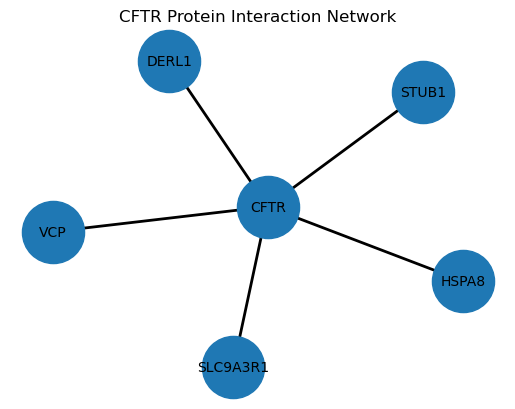

In [16]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

G.add_edges_from([
    ("CFTR", "HSPA8"),
    ("CFTR", "SLC9A3R1"),
    ("CFTR", "VCP"),
    ("CFTR", "STUB1"),
    ("CFTR", "DERL1")
])

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=2000
)

nx.draw_networkx_edges(
    G,
    pos,
    width=2
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10
)

plt.title("CFTR Protein Interaction Network")
plt.axis("off")
plt.show()

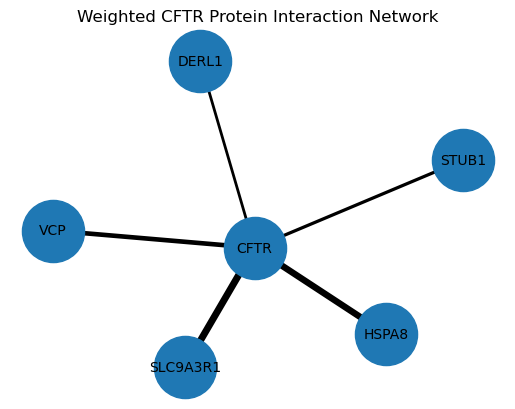

In [17]:
import networkx as nx
import matplotlib.pyplot as plt

G_weighted = nx.Graph()

edges_with_weights = [
    ("CFTR", "HSPA8", 14),
    ("CFTR", "SLC9A3R1", 15),
    ("CFTR", "VCP", 10),
    ("CFTR", "STUB1", 7),
    ("CFTR", "DERL1", 6)
]

G_weighted.add_weighted_edges_from(edges_with_weights)

pos = nx.spring_layout(G_weighted, seed=42)

edge_widths = [
    G_weighted[u][v]["weight"] / 3
    for u, v in G_weighted.edges()
]

nx.draw_networkx_nodes(
    G_weighted,
    pos,
    node_size=2000
)

nx.draw_networkx_edges(
    G_weighted,
    pos,
    width=edge_widths
)

nx.draw_networkx_labels(
    G_weighted,
    pos,
    font_size=10
)

plt.title("Weighted CFTR Protein Interaction Network")
plt.axis("off")
plt.show()

In [18]:
top10_proteins = interactor_summary.head(10).index.tolist()

top10_proteins

['HSPA8',
 'SLC9A3R1',
 'VCP',
 'STUB1',
 'DERL1',
 'HSP90AA1',
 'HSPA4',
 'DNAJA1',
 'HSPB1',
 'CANX']

In [19]:
expanded_proteins = ["CFTR"] + top10_proteins

expanded_proteins

['CFTR',
 'HSPA8',
 'SLC9A3R1',
 'VCP',
 'STUB1',
 'DERL1',
 'HSP90AA1',
 'HSPA4',
 'DNAJA1',
 'HSPB1',
 'CANX']

In [20]:
expanded_edges = physical_df[
    physical_df["Official Symbol Interactor A"].isin(expanded_proteins) &
    physical_df["Official Symbol Interactor B"].isin(expanded_proteins)
].copy()

In [21]:
expanded_edges[
    [
        "Official Symbol Interactor A",
        "Official Symbol Interactor B",
        "Experimental System"
    ]
]

,Official Symbol Interactor A,Official Symbol Interactor B,Experimental System
3,CFTR,SLC9A3R1,Reconstituted Complex
4,SLC9A3R1,CFTR,Reconstituted Complex
5,CFTR,SLC9A3R1,Affinity Capture-Western
8,CFTR,HSPA8,Affinity Capture-Western
10,CFTR,DNAJA1,Affinity Capture-Western
...,...,...,...
1543,CFTR,HSP90AA1,Affinity Capture-MS
1544,CFTR,HSPB1,Affinity Capture-MS
1555,CFTR,HSPA8,Affinity Capture-MS
1577,CFTR,VCP,Affinity Capture-MS


In [22]:
non_cftr_edges = expanded_edges[
    (expanded_edges["Official Symbol Interactor A"] != "CFTR") &
    (expanded_edges["Official Symbol Interactor B"] != "CFTR")
]

non_cftr_edges[
    [
        "Official Symbol Interactor A",
        "Official Symbol Interactor B",
        "Experimental System"
    ]
]

,Official Symbol Interactor A,Official Symbol Interactor B,Experimental System


In [23]:
non_cftr_pairs = (
    non_cftr_edges[
        [
            "Official Symbol Interactor A",
            "Official Symbol Interactor B"
        ]
    ]
    .drop_duplicates()
)

non_cftr_pairs

,Official Symbol Interactor A,Official Symbol Interactor B


In [24]:
second_degree_edges = physical_df[
    (
        physical_df["Official Symbol Interactor A"].isin(expanded_proteins)
    ) |
    (
        physical_df["Official Symbol Interactor B"].isin(expanded_proteins)
    )
].copy()

In [25]:
second_degree_edges.shape

(1946, 25)

In [26]:
second_degree_edges[
    [
        "Official Symbol Interactor A",
        "Official Symbol Interactor B",
        "Experimental System"
    ]
].head(20)

,Official Symbol Interactor A,Official Symbol Interactor B,Experimental System
0,CFTR,GOPC,Two-hybrid
1,CFTR,KCNJ1,Affinity Capture-Western
2,CFTR,PDZD3,Reconstituted Complex
3,CFTR,SLC9A3R1,Reconstituted Complex
4,SLC9A3R1,CFTR,Reconstituted Complex
5,CFTR,SLC9A3R1,Affinity Capture-Western
6,STX1A,CFTR,Reconstituted Complex
7,STX1A,CFTR,Affinity Capture-Western
8,CFTR,HSPA8,Affinity Capture-Western
9,CFTR,DNAJB1,Affinity Capture-Western


In [27]:
import os

print("Jupyter is currently looking in:")
print(os.getcwd())

print("\nFiles in this folder:")
print(os.listdir())

Jupyter is currently looking in:
C:\Users\ANNA CAMILLE

Files in this folder:
['.anaconda', '.conda', '.dbvis', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.vscode', '3D Objects', 'anaconda3', 'AppData', 'Application Data', 'BIOGRID-GENE-107506-5.0.260.tab2.txt', 'BIOGRID-ORGANISM-Homo_sapiens-5.0.261.tab3.txt', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'expanded_bayesian_network.png', 'Favorites', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'New folder', 'New folder python', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TM.blf', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'Templates', 'Thesis.ipynb', 'Thesis1.ipynb', 'Videos']


In [28]:
import os

downloads = r"C:\Users\ANNA CAMILLE\Downloads"

print(os.listdir(downloads))

['.ipynb_checkpoints', '.Rhistory', '0213984c-fde7-40fa-a0ed-5235321ef691.jpg', '06MATH_Class_Syllabus (1).pdf', '06MATH_Class_Syllabus.pdf', '06MATH_pretest_answers.pdf', '06MATH_Pre_test.pdf', '07242026135149_CRCINDIncomplete_2513492.pdf', '07MATH_Class_Syllabus.pdf', '07Math_pretest_ans.pdf', '07MATH___7B_Pre_test.pdf', '100s-chart-for-groups-of-3.pdf', '12.2025 Private School Employee Handbook 12.2025 rvsd - Google Docs (1).pdf', '12.2025 Private School Employee Handbook 12.2025 rvsd - Google Docs.pdf', '12.2025 Private School New Employee Welcome Packet 12.2025 rvsd - Google Docs.pdf', '15e96fe6-fd05-4a0a-84d6-485bfa6b5c60.jpg', '1ae391f6-38dd-4498-904f-89470ffe02d9.jpg', '1aeb80ae-f776-4858-ab89-bf35f35e5764.jpg', '2 Matrix Algebra.pdf', '28647163-20a8-46ea-a29c-bb66b01f7374.jpg', '2bea08be-c0d5-403f-bd34-4b02ec3743e9.jpg', '2D&3D.R', '3. Multivariate Normal Model (1).pdf', '3. Multivariate Normal Model.pdf', '3. MVN.R', '37e5bde4-1508-4ca0-954c-801745588c93.jpg', '3d6affdf-01b7-

In [29]:
zip_path = r"C:\Users\ANNA CAMILLE\Downloads\BIOGRID-ORGANISM-5.0.261.tab3.zip"

In [30]:
import zipfile

zip_path = r"C:\Users\ANNA CAMILLE\Downloads\BIOGRID-ORGANISM-5.0.261.tab3.zip"

human_file = "BIOGRID-ORGANISM-Homo_sapiens-5.0.261.tab3.txt"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extract(human_file)

print("Human BioGRID file extracted!")

Human BioGRID file extracted!


In [31]:
import os

human_path = r"C:\Users\ANNA CAMILLE\BIOGRID-ORGANISM-Homo_sapiens-5.0.261.tab3.txt"

print("File exists:", os.path.exists(human_path))
print("File size:", round(os.path.getsize(human_path) / (1024**3), 2), "GB")

File exists: True
File size: 0.69 GB


In [32]:
import pandas as pd

human_path = r"C:\Users\ANNA CAMILLE\BIOGRID-ORGANISM-Homo_sapiens-5.0.261.tab3.txt"

sample = pd.read_csv(
    human_path,
    sep="\t",
    nrows=5
)

print("Number of columns:", len(sample.columns))
print("\nColumns:")
print(sample.columns.tolist())

Number of columns: 37

Columns:
['#BioGRID Interaction ID', 'Entrez Gene Interactor A', 'Entrez Gene Interactor B', 'BioGRID ID Interactor A', 'BioGRID ID Interactor B', 'Systematic Name Interactor A', 'Systematic Name Interactor B', 'Official Symbol Interactor A', 'Official Symbol Interactor B', 'Synonyms Interactor A', 'Synonyms Interactor B', 'Experimental System', 'Experimental System Type', 'Author', 'Publication Source', 'Organism ID Interactor A', 'Organism ID Interactor B', 'Throughput', 'Score', 'Modification', 'Qualifications', 'Tags', 'Source Database', 'SWISS-PROT Accessions Interactor A', 'TREMBL Accessions Interactor A', 'REFSEQ Accessions Interactor A', 'SWISS-PROT Accessions Interactor B', 'TREMBL Accessions Interactor B', 'REFSEQ Accessions Interactor B', 'Ontology Term IDs', 'Ontology Term Names', 'Ontology Term Categories', 'Ontology Term Qualifier IDs', 'Ontology Term Qualifier Names', 'Ontology Term Types', 'Organism Name Interactor A', 'Organism Name Interactor B'

In [33]:
with open(human_path, "r", encoding="utf-8") as f:
    row_count = sum(1 for _ in f) - 1

print("Number of interaction records:", row_count)

Number of interaction records: 1422529


In [34]:
import pandas as pd

proteins = [
    "CFTR",
    "HSPA8",
    "SLC9A3R1",
    "VCP",
    "STUB1",
    "DERL1"
]

matches = []

for chunk in pd.read_csv(
    human_path,
    sep="\t",
    chunksize=100000,
    low_memory=False
):
    filtered = chunk[
        chunk["Official Symbol Interactor A"].isin(proteins) |
        chunk["Official Symbol Interactor B"].isin(proteins)
    ]

    matches.append(filtered)

network_data = pd.concat(matches, ignore_index=True)

print("Matching interaction records:", len(network_data))

Matching interaction records: 10505


In [37]:
candidate_edges = network_data[
    network_data["Official Symbol Interactor A"].isin(proteins) &
    network_data["Official Symbol Interactor B"].isin(proteins)
].copy()

print("Interaction records among our six proteins:", len(candidate_edges))

Interaction records among our six proteins: 209


In [38]:
candidate_edges["Protein_1"] = candidate_edges[
    ["Official Symbol Interactor A", "Official Symbol Interactor B"]
].min(axis=1)

candidate_edges["Protein_2"] = candidate_edges[
    ["Official Symbol Interactor A", "Official Symbol Interactor B"]
].max(axis=1)

pair_summary = (
    candidate_edges
    .groupby(["Protein_1", "Protein_2"])
    .agg(
        Interaction_Records=("#BioGRID Interaction ID", "count"),
        Publications=("Publication Source", "nunique"),
        Experimental_Systems=("Experimental System", "nunique")
    )
    .reset_index()
    .sort_values(
        ["Protein_1", "Protein_2"]
    )
)

pair_summary

,Protein_1,Protein_2,Interaction_Records,Publications,Experimental_Systems
0,CFTR,CFTR,5,5,3
1,CFTR,DERL1,6,5,2
2,CFTR,HSPA8,14,12,4
3,CFTR,SLC9A3R1,15,10,4
4,CFTR,STUB1,7,7,2
5,CFTR,VCP,10,8,2
6,DERL1,DERL1,1,1,1
7,DERL1,HSPA8,1,1,1
8,DERL1,VCP,18,16,6
9,HSPA8,HSPA8,6,5,3


In [39]:
pair_summary_no_self = pair_summary[
    pair_summary["Protein_1"] != pair_summary["Protein_2"]
].copy()

print("Unique protein pairs:", len(pair_summary_no_self))

pair_summary_no_self

Unique protein pairs: 10


,Protein_1,Protein_2,Interaction_Records,Publications,Experimental_Systems
1,CFTR,DERL1,6,5,2
2,CFTR,HSPA8,14,12,4
3,CFTR,SLC9A3R1,15,10,4
4,CFTR,STUB1,7,7,2
5,CFTR,VCP,10,8,2
7,DERL1,HSPA8,1,1,1
8,DERL1,VCP,18,16,6
10,HSPA8,STUB1,52,37,11
11,HSPA8,VCP,7,7,3
14,STUB1,VCP,3,3,2


In [40]:
import networkx as nx
import matplotlib.pyplot as plt

G_expanded = nx.Graph()

# Add the six proteins as nodes
G_expanded.add_nodes_from(proteins)

# Add edges with BioGRID interaction-record counts as weights
for _, row in pair_summary_no_self.iterrows():
    G_expanded.add_edge(
        row["Protein_1"],
        row["Protein_2"],
        weight=row["Interaction_Records"]
    )

print("Number of nodes:", G_expanded.number_of_nodes())
print("Number of edges:", G_expanded.number_of_edges())

Number of nodes: 6
Number of edges: 10


In [41]:
for u, v, data in G_expanded.edges(data=True):
    print(f"{u} -- {v}: {data['weight']} records")

CFTR -- DERL1: 6 records
CFTR -- HSPA8: 14 records
CFTR -- SLC9A3R1: 15 records
CFTR -- STUB1: 7 records
CFTR -- VCP: 10 records
HSPA8 -- DERL1: 1 records
HSPA8 -- STUB1: 52 records
HSPA8 -- VCP: 7 records
VCP -- DERL1: 18 records
VCP -- STUB1: 3 records


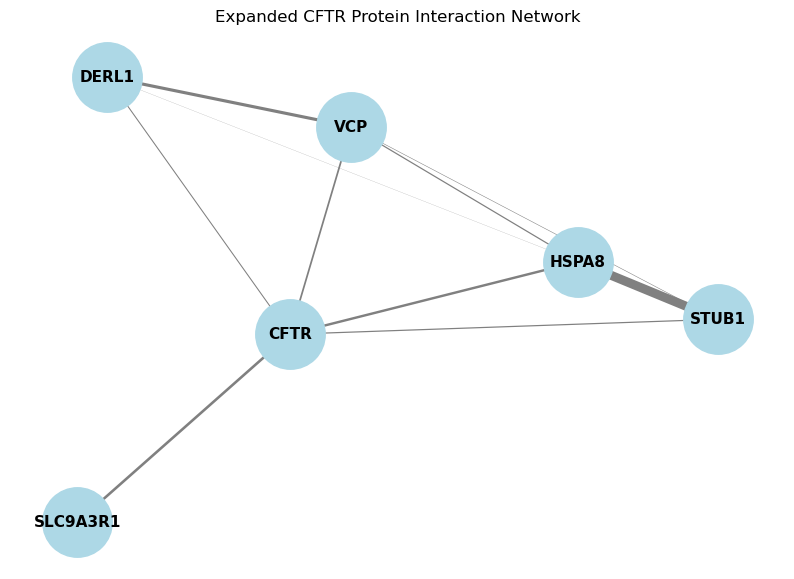

In [42]:
plt.figure(figsize=(10, 7))

pos = nx.spring_layout(G_expanded, seed=42)

weights = [
    G_expanded[u][v]["weight"]
    for u, v in G_expanded.edges()
]

nx.draw_networkx(
    G_expanded,
    pos,
    with_labels=True,
    node_size=2500,
    node_color="lightblue",
    edge_color="gray",
    width=[w / 8 for w in weights],
    font_size=11,
    font_weight="bold"
)

plt.title("Expanded CFTR Protein Interaction Network")
plt.axis("off")
plt.show()

In [63]:
# Prepare the publication-level data for pgmpy

pgm_data = publication_matrix[proteins].copy()

print("PGM data shape:", pgm_data.shape)
print()
display(pgm_data.head())

PGM data shape: (130, 6)



,CFTR,HSPA8,SLC9A3R1,VCP,STUB1,DERL1
0,1,1,0,0,0,0
1,0,1,0,0,1,0
2,0,0,0,1,0,0
3,1,1,0,0,0,0
4,1,0,1,0,0,0


In [64]:
from pgmpy.estimators import HillClimbSearch, BIC

# Create the structure-learning estimator
estimator = HillClimbSearch(pgm_data)

# Use BIC to score candidate network structures
bic = BIC(pgm_data)

# Learn the directed structure
learned_structure = estimator.estimate(
    scoring_method=bic
)

print("Learned edges:")
print(list(learned_structure.edges()))

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

Learned edges:
[('CFTR', 'SLC9A3R1'), ('CFTR', 'STUB1'), ('SLC9A3R1', 'STUB1'), ('VCP', 'STUB1'), ('STUB1', 'DERL1'), ('STUB1', 'HSPA8')]


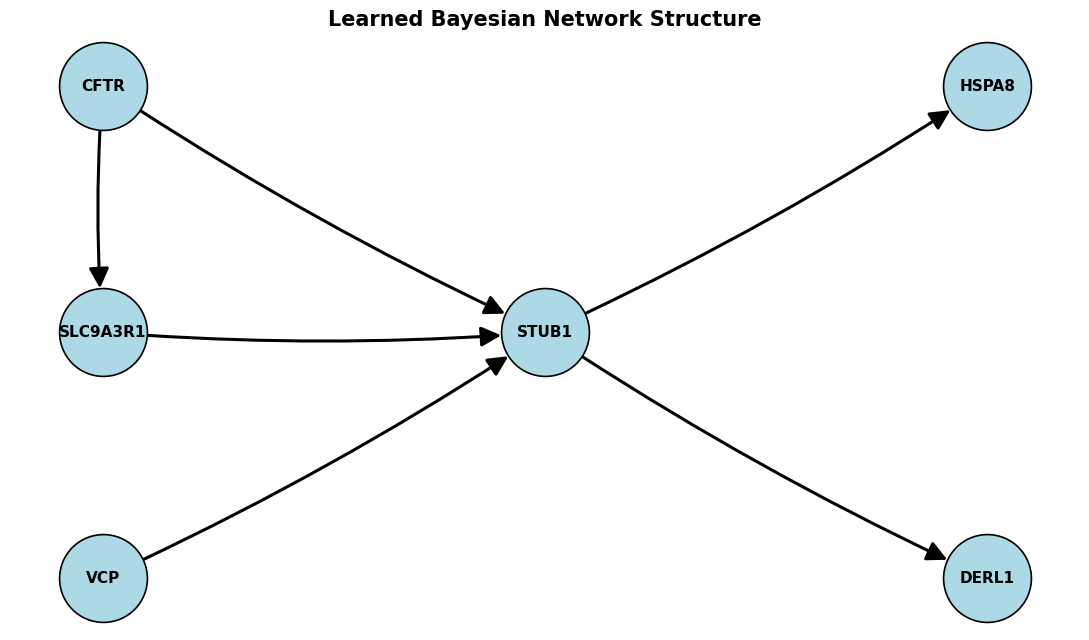

In [65]:
import networkx as nx
import matplotlib.pyplot as plt

# Create directed graph
dag = nx.DiGraph()
dag.add_edges_from(learned_structure.edges())

# Clean, intentional layout
pos = {
    "CFTR": (-2.5, 1),
    "SLC9A3R1": (-2.5, 0),
    "VCP": (-2.5, -1),
    "STUB1": (0, 0),
    "HSPA8": (2.5, 1),
    "DERL1": (2.5, -1)
}

plt.figure(figsize=(11, 6.5))

# Nodes
nx.draw_networkx_nodes(
    dag,
    pos,
    node_size=4000,
    node_color="lightblue",
    edgecolors="black",
    linewidths=1.2
)

# Directed edges with large, obvious arrowheads
nx.draw_networkx_edges(
    dag,
    pos,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=30,
    width=2.2,
    edge_color="black",
    node_size=4000,
    min_source_margin=12,
    min_target_margin=18,
    connectionstyle="arc3,rad=0.04"
)

# Labels
nx.draw_networkx_labels(
    dag,
    pos,
    font_size=11,
    font_weight="bold"
)

plt.title(
    "Learned Bayesian Network Structure",
    fontsize=15,
    fontweight="bold"
)

plt.axis("off")
plt.tight_layout()
plt.show()

In [44]:
import pgmpy

print("pgmpy version:", pgmpy.__version__)

pgmpy version: 1.0.0


In [45]:
from pgmpy.models import BayesianNetwork

print("BayesianNetwork imported successfully!")

BayesianNetwork imported successfully!


In [46]:
from pgmpy.models import DiscreteBayesianNetwork

small_model = DiscreteBayesianNetwork([
    ("CFTR", "HSPA8")
])

print("Nodes:", list(small_model.nodes()))
print("Edges:", list(small_model.edges()))

Nodes: ['CFTR', 'HSPA8']
Edges: [('CFTR', 'HSPA8')]


In [47]:
from pgmpy.factors.discrete import TabularCPD

cftr_cpd = TabularCPD(
    variable="CFTR",
    variable_card=2,
    values=[
        [0.70],
        [0.30]
    ],
    state_names={
        "CFTR": ["0", "1"]
    }
)

print(cftr_cpd)

+---------+-----+
| CFTR(0) | 0.7 |
+---------+-----+
| CFTR(1) | 0.3 |
+---------+-----+


In [48]:
hspa8_cpd = TabularCPD(
    variable="HSPA8",
    variable_card=2,
    values=[
        [0.80, 0.30],
        [0.20, 0.70]
    ],
    evidence=["CFTR"],
    evidence_card=[2],
    state_names={
        "HSPA8": ["0", "1"],
        "CFTR": ["0", "1"]
    }
)

print(hspa8_cpd)

+----------+---------+---------+
| CFTR     | CFTR(0) | CFTR(1) |
+----------+---------+---------+
| HSPA8(0) | 0.8     | 0.3     |
+----------+---------+---------+
| HSPA8(1) | 0.2     | 0.7     |
+----------+---------+---------+


In [49]:
small_model.add_cpds(cftr_cpd, hspa8_cpd)

print("CPDs added successfully!")
print()
print(small_model.get_cpds())

CPDs added successfully!

[<TabularCPD representing P(CFTR:2) at 0x28821b2f0e0>, <TabularCPD representing P(HSPA8:2 | CFTR:2) at 0x28821b84e10>]


In [50]:
print("Model valid:", small_model.check_model())

Model valid: True


In [51]:
from pgmpy.inference import VariableElimination

inference = VariableElimination(small_model)

result = inference.query(
    variables=["HSPA8"],
    evidence={"CFTR": "1"}
)

print(result)

+----------+--------------+
| HSPA8    |   phi(HSPA8) |
+==========+==============+
| HSPA8(0) |       0.3000 |
+----------+--------------+
| HSPA8(1) |       0.7000 |
+----------+--------------+


In [52]:
# Check for missing values in the interaction data

missing_values = candidate_edges[
    [
        "Official Symbol Interactor A",
        "Official Symbol Interactor B",
        "Experimental System",
        "Experimental System Type",
        "Organism ID Interactor A",
        "Organism ID Interactor B"
    ]
].isna().sum()

print(missing_values)

Official Symbol Interactor A    0
Official Symbol Interactor B    0
Experimental System             0
Experimental System Type        0
Organism ID Interactor A        0
Organism ID Interactor B        0
dtype: int64


In [53]:
# Check for exact duplicate interaction records

duplicate_count = candidate_edges.duplicated().sum()

print("Duplicate records:", duplicate_count)

Duplicate records: 0


In [54]:
# Create the cleaned edge list for the six-protein network

edge_list = pair_summary_no_self[
    [
        "Protein_1",
        "Protein_2",
        "Interaction_Records",
        "Publications",
        "Experimental_Systems"
    ]
].copy()

print("Clean edge list:")
display(edge_list)

Clean edge list:


,Protein_1,Protein_2,Interaction_Records,Publications,Experimental_Systems
1,CFTR,DERL1,6,5,2
2,CFTR,HSPA8,14,12,4
3,CFTR,SLC9A3R1,15,10,4
4,CFTR,STUB1,7,7,2
5,CFTR,VCP,10,8,2
7,DERL1,HSPA8,1,1,1
8,DERL1,VCP,18,16,6
10,HSPA8,STUB1,52,37,11
11,HSPA8,VCP,7,7,3
14,STUB1,VCP,3,3,2


In [55]:
# Examine the experimental systems represented
# in the 209 interaction records

experimental_systems = (
    candidate_edges["Experimental System"]
    .value_counts()
    .reset_index()
)

experimental_systems.columns = [
    "Experimental_System",
    "Interaction_Records"
]

print("Number of experimental systems:",
      len(experimental_systems))

display(experimental_systems)

Number of experimental systems: 14


,Experimental_System,Interaction_Records
0,Affinity Capture-Western,58
1,Biochemical Activity,41
2,Affinity Capture-MS,36
3,Reconstituted Complex,33
4,Co-crystal Structure,10
5,Co-fractionation,6
6,Protein-peptide,6
7,Cross-Linking-MS (XL-MS),6
8,Two-hybrid,3
9,Affinity Capture-Luminescence,3


In [56]:
# Examine the experimental system types in our candidate interactions

candidate_edges[
    [
        "Official Symbol Interactor A",
        "Official Symbol Interactor B",
        "Experimental System",
        "Experimental System Type",
        "Throughput",
        "Score"
    ]
].head(20)

,Official Symbol Interactor A,Official Symbol Interactor B,Experimental System,Experimental System Type,Throughput,Score
23,SLC9A3R1,SLC9A3R1,Reconstituted Complex,physical,Low Throughput,-
34,VCP,VCP,Co-fractionation,physical,Low Throughput,-
39,CFTR,SLC9A3R1,Reconstituted Complex,physical,Low Throughput,-
56,SLC9A3R1,CFTR,Reconstituted Complex,physical,Low Throughput,-
57,CFTR,SLC9A3R1,Affinity Capture-Western,physical,Low Throughput,-
75,CFTR,HSPA8,Affinity Capture-Western,physical,Low Throughput,-
110,SLC9A3R1,CFTR,Affinity Capture-Western,physical,Low Throughput,-
112,VCP,VCP,Affinity Capture-Western,physical,Low Throughput,-
115,SLC9A3R1,CFTR,Reconstituted Complex,physical,Low Throughput,-
130,SLC9A3R1,SLC9A3R1,Far Western,physical,Low Throughput,-


In [57]:
# Examine the publication information for our candidate interactions

candidate_edges[
    [
        "#BioGRID Interaction ID",
        "Official Symbol Interactor A",
        "Official Symbol Interactor B",
        "Publication Source",
        "Experimental System"
    ]
].head(20)

,#BioGRID Interaction ID,Official Symbol Interactor A,Official Symbol Interactor B,Publication Source,Experimental System
23,251983,SLC9A3R1,SLC9A3R1,PUBMED:15070904,Reconstituted Complex
34,258255,VCP,VCP,PUBMED:12807884,Co-fractionation
39,260080,CFTR,SLC9A3R1,PUBMED:12615054,Reconstituted Complex
56,275985,SLC9A3R1,CFTR,PUBMED:9613608,Reconstituted Complex
57,275986,CFTR,SLC9A3R1,PUBMED:9613608,Affinity Capture-Western
75,278424,CFTR,HSPA8,PUBMED:10075921,Affinity Capture-Western
110,288282,SLC9A3R1,CFTR,PUBMED:10852925,Affinity Capture-Western
112,301594,VCP,VCP,PUBMED:17525332,Affinity Capture-Western
115,302278,SLC9A3R1,CFTR,PUBMED:12471024,Reconstituted Complex
130,302810,SLC9A3R1,SLC9A3R1,PUBMED:11046132,Far Western


In [58]:
# Count unique publications for the six selected proteins

publication_counts = (
    candidate_edges
    .groupby("Publication Source")
    .size()
    .reset_index(name="Interaction_Records")
    .sort_values("Interaction_Records", ascending=False)
)

print("Number of unique publications:",
      publication_counts["Publication Source"].nunique())

display(publication_counts.head(20))

Number of unique publications: 130


,Publication Source,Interaction_Records
81,PUBMED:26618866,5
100,PUBMED:31324722,5
8,PUBMED:11146634,4
37,PUBMED:17272822,4
98,PUBMED:29568061,4
35,PUBMED:17110338,4
117,PUBMED:36027913,4
34,PUBMED:16954204,4
113,PUBMED:35398354,4
30,PUBMED:16621797,4


In [59]:
# Count how many unique publications contain each protein

protein_publication_counts = {}

for protein in proteins:
    rows = candidate_edges[
        (candidate_edges["Official Symbol Interactor A"] == protein) |
        (candidate_edges["Official Symbol Interactor B"] == protein)
    ]
    
    protein_publication_counts[protein] = rows["Publication Source"].nunique()

protein_publication_counts

{'CFTR': 33, 'HSPA8': 57, 'SLC9A3R1': 14, 'VCP': 46, 'STUB1': 66, 'DERL1': 21}

In [60]:
# Create a publication-level observation matrix

publication_protein_data = []

for publication, group in candidate_edges.groupby("Publication Source"):
    
    row = {"Publication": publication}
    
    for protein in proteins:
        present = (
            (group["Official Symbol Interactor A"] == protein) |
            (group["Official Symbol Interactor B"] == protein)
        ).any()
        
        row[protein] = int(present)
    
    publication_protein_data.append(row)

publication_matrix = pd.DataFrame(publication_protein_data)

print("Number of observations:", len(publication_matrix))
print("Number of protein variables:", len(proteins))

display(publication_matrix.head(20))

Number of observations: 130
Number of protein variables: 6


,Publication,CFTR,HSPA8,SLC9A3R1,VCP,STUB1,DERL1
0,PUBMED:10075921,1,1,0,0,0,0
1,PUBMED:10330192,0,1,0,0,1,0
2,PUBMED:10350210,0,0,0,1,0,0
3,PUBMED:10666020,1,1,0,0,0,0
4,PUBMED:10852925,1,0,1,0,0,0
5,PUBMED:10982807,1,1,0,0,0,0
6,PUBMED:11046132,0,0,1,0,0,0
7,PUBMED:11051556,1,0,0,0,0,0
8,PUBMED:11146634,1,1,0,0,1,0
9,PUBMED:11533036,0,0,1,0,0,0


In [61]:
# Check how often each protein appears across publications

protein_frequencies = publication_matrix[proteins].sum().sort_values(
    ascending=False
)

print("Number of publications containing each protein:")
display(protein_frequencies)

print("\nProportion of publications containing each protein:")
display((protein_frequencies / len(publication_matrix)).round(3))

Number of publications containing each protein:


STUB1       66
HSPA8       57
VCP         46
CFTR        33
DERL1       21
SLC9A3R1    14
dtype: int64


Proportion of publications containing each protein:


STUB1       0.508
HSPA8       0.438
VCP         0.354
CFTR        0.254
DERL1       0.162
SLC9A3R1    0.108
dtype: float64

In [62]:
# Prepare the publication-level data for pgmpy

pgm_data = publication_matrix[proteins].copy()

print("PGM data shape:", pgm_data.shape)
print()
display(pgm_data.head())

PGM data shape: (130, 6)



,CFTR,HSPA8,SLC9A3R1,VCP,STUB1,DERL1
0,1,1,0,0,0,0
1,0,1,0,0,1,0
2,0,0,0,1,0,0
3,1,1,0,0,0,0
4,1,0,1,0,0,0


In [ ]:
from pgmpy.estimators import HillClimbSearch, BIC

# Create the structure-learning estimator
estimator = HillClimbSearch(pgm_data)

# Use BIC to score candidate network structures
bic = BIC(pgm_data)

# Learn the directed structure
learned_structure = estimator.estimate(
    scoring_method=bic
)

print("Learned edges:")
print(list(learned_structure.edges()))

In [ ]:
from pgmpy.models import DiscreteBayesianNetwork

# Create the Bayesian network from the learned structure
pgm_model = DiscreteBayesianNetwork(
    list(learned_structure.edges())
)

print("Nodes:")
print(list(pgm_model.nodes()))

print("\nDirected edges:")
print(list(pgm_model.edges()))

In [ ]:
from pgmpy.estimators import MaximumLikelihoodEstimator

# Learn the conditional probability distributions from the data
pgm_model.fit(
    pgm_data,
    estimator=MaximumLikelihoodEstimator
)

print("CPDs learned successfully.")
print()

for cpd in pgm_model.get_cpds():
    print(cpd)
    print()

In [ ]:
from pgmpy.estimators import BayesianEstimator

pgm_model.fit(
    pgm_data,
    estimator=BayesianEstimator,
    prior_type="BDeu",
    equivalent_sample_size=10
)

for cpd in pgm_model.get_cpds():
    print(cpd)

In [ ]:
from pgmpy.inference import VariableElimination

inference = VariableElimination(pgm_model)

for protein in pgm_data.columns:
    result = inference.query([protein])
    print(protein)
    print(result)

In [ ]:
# Check whether the Bayesian network is valid

model_valid = pgm_model.check_model()

print("Model valid:", model_valid)

In [ ]:
result = inference.query(
    variables=["STUB1"],
    evidence={"CFTR": 1}
)

print(result)

In [ ]:
result = inference.query(
    variables=["STUB1"],
    evidence={
        "CFTR": 1,
        "VCP": 1
    }
)

print(result)

In [ ]:
from pgmpy.inference import VariableElimination

# Create an inference engine for the Bayesian network
inference = VariableElimination(pgm_model)

# Query the probability of SLC9A3R1 given CFTR = 1
result = inference.query(
    variables=["SLC9A3R1"],
    evidence={"CFTR": 1}
)

print(result)

In [ ]:
# Query the probability of STUB1 given CFTR = 1

result = inference.query(
    variables=["STUB1"],
    evidence={"CFTR": 1}
)

print(result)

In [ ]:
# Query the probability of STUB1 without any evidence

result = inference.query(
    variables=["STUB1"]
)

print(result)

In [ ]:
# Query STUB1 given both CFTR and SLC9A3R1

result = inference.query(
    variables=["STUB1"],
    evidence={
        "CFTR": 1,
        "SLC9A3R1": 1
    }
)

print(result)

In [ ]:
# Examine observations where both CFTR and SLC9A3R1 are present

both_present = publication_matrix[
    (publication_matrix["CFTR"] == 1) &
    (publication_matrix["SLC9A3R1"] == 1)
]

print("Observations with CFTR = 1 and SLC9A3R1 = 1:",
      len(both_present))

display(both_present)

In [ ]:
# Examine how many observations exist for each parent combination of STUB1

stub1_parent_counts = (
    pgm_data
    .groupby(["CFTR", "SLC9A3R1", "VCP"])
    .size()
    .reset_index(name="Observations")
)

display(stub1_parent_counts)

In [ ]:
# Display only the learned CPD for STUB1

stub1_cpd = pgm_model.get_cpds("STUB1")

print(stub1_cpd)

In [ ]:
from pgmpy.estimators import BayesianEstimator

# Re-estimate the CPDs using Bayesian parameter estimation
pgm_model.fit(
    pgm_data,
    estimator=BayesianEstimator,
    prior_type="BDeu",
    equivalent_sample_size=10
)

print("Bayesian CPDs learned successfully.")
print()

for cpd in pgm_model.get_cpds():
    print(cpd)
    print()

In [ ]:
# Validate the Bayesian network after Bayesian parameter estimation

model_valid = pgm_model.check_model()

print("Model valid:", model_valid)

In [ ]:
# Create the inference engine using the updated Bayesian CPDs

inference = VariableElimination(pgm_model)

# Query STUB1 given CFTR = 1 and SLC9A3R1 = 1
result = inference.query(
    variables=["STUB1"],
    evidence={
        "CFTR": 1,
        "SLC9A3R1": 1
    }
)

print(result)

In [ ]:
# Display the final learned network structure

print("Number of nodes:", pgm_model.number_of_nodes())
print("Number of edges:", pgm_model.number_of_edges())

print("\nDirected edges:")
for edge in pgm_model.edges():
    print(f"{edge[0]} -> {edge[1]}")

In [ ]:
# Proteins selected for the expanded model

expanded_proteins = [
    "CFTR",
    "HSPA8",
    "SLC9A3R1",
    "VCP",
    "STUB1",
    "DERL1",
    "HSP90AA1",
    "HSPA4",
    "DNAJA1",
    "HSPB1",
    "CANX"
]

# Check the number of publications containing each protein

expanded_publication_counts = {}

for protein in expanded_proteins:
    rows = network_data[
        (network_data["Official Symbol Interactor A"] == protein) |
        (network_data["Official Symbol Interactor B"] == protein)
    ]
    
    expanded_publication_counts[protein] = (
        rows["Publication Source"].nunique()
    )

print("Publication counts for expanded protein set:")

for protein, count in expanded_publication_counts.items():
    print(f"{protein}: {count}")

In [68]:
# Create the expanded publication-level observation matrix

expanded_publication_data = []

for publication, group in network_data.groupby("Publication Source"):
    
    row = {"Publication": publication}
    
    for protein in expanded_proteins:
        present = (
            (group["Official Symbol Interactor A"] == protein) |
            (group["Official Symbol Interactor B"] == protein)
        ).any()
        
        row[protein] = int(present)
    
    expanded_publication_data.append(row)

expanded_publication_matrix = pd.DataFrame(
    expanded_publication_data
)

print(
    "Number of observations:",
    len(expanded_publication_matrix)
)

print(
    "Number of protein variables:",
    len(expanded_proteins)
)

display(expanded_publication_matrix.head(10))

Number of observations: 1668
Number of protein variables: 11


,Publication,CFTR,HSPA8,SLC9A3R1,VCP,STUB1,DERL1,HSP90AA1,HSPA4,DNAJA1,HSPB1,CANX
0,DOI:10.1101/2020.08.28.269175,0,0,0,0,0,1,0,0,0,0,0
1,DOI:10.1101/2020.08.28.272955,0,1,1,1,1,1,0,0,0,0,0
2,DOI:10.1101/2020.09.03.282103,0,1,1,0,1,1,0,0,0,0,0
3,DOI:10.1101/2020.12.31.424961,0,1,0,0,0,0,0,0,0,0,0
4,DOI:10.1101/2022.01.18.476803,1,0,0,0,0,0,0,0,0,0,0
5,DOI:10.1101/2022.09.27.509702,0,1,0,1,0,0,0,0,0,0,0
6,DOI:10.1101/2022.10.19.512927,0,0,1,0,0,0,0,0,0,0,0
7,DOI:10.1101/2023.05.15.540806,0,1,0,0,0,0,0,0,0,0,0
8,DOI:10.1101/2023.12.03.569805,0,0,0,0,1,0,0,0,0,0,0
9,PUBMED:10075921,1,1,0,0,0,0,0,0,1,0,0


In [52]:
# Check protein frequencies in the expanded dataset

expanded_frequencies = (
    expanded_publication_matrix[expanded_proteins]
    .sum()
    .sort_values(ascending=False)
)

expanded_proportions = (
    expanded_frequencies / len(expanded_publication_matrix)
).round(3)

print("Number of publications containing each protein:")
display(expanded_frequencies)

print("Proportion of publications containing each protein:")
display(expanded_proportions)

Number of publications containing each protein:


HSPA8       722
VCP         596
STUB1       560
SLC9A3R1    114
DERL1       113
CFTR         84
HSPA4        80
HSP90AA1     57
DNAJA1       14
HSPB1        11
CANX         11
dtype: int64

Proportion of publications containing each protein:


HSPA8       0.433
VCP         0.357
STUB1       0.336
SLC9A3R1    0.068
DERL1       0.068
CFTR        0.050
HSPA4       0.048
HSP90AA1    0.034
DNAJA1      0.008
HSPB1       0.007
CANX        0.007
dtype: float64

In [75]:
from pgmpy.estimators import HillClimbSearch, BIC

# Create the structure-learning estimator
expanded_estimator = HillClimbSearch(expanded_publication_matrix[expanded_proteins])

# Learn the directed network structure using BIC
expanded_structure = expanded_estimator.estimate(
    scoring_method=BIC(expanded_publication_matrix[expanded_proteins])
)

print("Learned edges:")
for edge in expanded_structure.edges():
    print(f"{edge[0]} -> {edge[1]}")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

Learned edges:
CFTR -> STUB1
HSPA8 -> STUB1
HSPA8 -> CFTR
HSPA8 -> DNAJA1
HSPA8 -> HSP90AA1
SLC9A3R1 -> STUB1
SLC9A3R1 -> HSPA8
VCP -> STUB1
VCP -> HSPA8
VCP -> CFTR
VCP -> DERL1
VCP -> CANX
STUB1 -> HSPA4
STUB1 -> HSP90AA1
DERL1 -> STUB1
DERL1 -> HSPA8
HSP90AA1 -> HSPA4
HSP90AA1 -> CANX
DNAJA1 -> HSPA4
HSPB1 -> DNAJA1
CANX -> HSPB1


In [54]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator

# Create the expanded Bayesian network
expanded_pgm = DiscreteBayesianNetwork(
    list(expanded_structure.edges())
)

# Learn the CPDs using Bayesian parameter estimation
expanded_pgm.fit(
    expanded_publication_matrix[expanded_proteins],
    estimator=BayesianEstimator,
    prior_type="BDeu",
    equivalent_sample_size=10
)

print("Expanded Bayesian network fitted successfully.")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}


Expanded Bayesian network fitted successfully.


In [4]:
# Validate the expanded Bayesian network

expanded_valid = expanded_pgm.check_model()

print("Expanded model valid:", expanded_valid)

NameError: name 'expanded_pgm' is not defined

In [56]:
# Examine the number of parents for each protein

parent_counts = {
    protein: len(list(expanded_pgm.predecessors(protein)))
    for protein in expanded_pgm.nodes()
}

parent_counts = pd.Series(parent_counts).sort_values(ascending=False)

print("Number of parents for each protein:")
display(parent_counts)

Number of parents for each protein:


STUB1       5
HSPA8       3
HSPA4       3
CFTR        2
DNAJA1      2
HSP90AA1    2
CANX        2
DERL1       1
HSPB1       1
SLC9A3R1    0
VCP         0
dtype: int64

In [151]:
# Create an inference engine for the expanded PGM

expanded_inference = VariableElimination(expanded_pgm)

# Query the marginal probability of CFTR
result = expanded_inference.query(
    variables=["CFTR"]
)

print(result)

+---------+-------------+
| CFTR    |   phi(CFTR) |
+=========+=============+
| CFTR(0) |      0.9471 |
+---------+-------------+
| CFTR(1) |      0.0529 |
+---------+-------------+


In [ ]:
# Query CFTR given HSPA8 = 1

result = expanded_inference.query(
    variables=["CFTR"],
    evidence={"HSPA8": 1}
)

print(result)

In [ ]:
# Query CFTR given VCP = 1

result = expanded_inference.query(
    variables=["CFTR"],
    evidence={"VCP": 1}
)

print(result)

In [ ]:
# Query CFTR given both HSPA8 and VCP

result = expanded_inference.query(
    variables=["CFTR"],
    evidence={
        "HSPA8": 1,
        "VCP": 1
    }
)

print(result)

In [ ]:
result = expanded_inference.query(
    variables=["STUB1"],
    evidence={
        "CFTR": 1
    }
)

print(result)

In [ ]:
result = expanded_inference.query(
    variables=["STUB1"]
)

print(result)


In [ ]:
result = expanded_inference.query(
    variables=["STUB1"],
    evidence={
        "CFTR": 1,
        "VCP": 1
    }
)

print(result)

In [ ]:
result = expanded_inference.query(
    variables=["STUB1"],
    evidence={
        "CFTR": 1,
        "HSPA8": 1,
        "VCP": 1
    }
)

print(result)

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Exact learned Bayesian network structure
learned_edges = [
    ("CFTR", "STUB1"),
    ("HSPA8", "STUB1"),
    ("HSPA8", "CFTR"),
    ("HSPA8", "DNAJA1"),
    ("HSPA8", "HSP90AA1"),
    ("SLC9A3R1", "STUB1"),
    ("SLC9A3R1", "HSPA8"),
    ("VCP", "STUB1"),
    ("VCP", "HSPA8"),
    ("VCP", "CFTR"),
    ("VCP", "DERL1"),
    ("VCP", "HSPB1"),
    ("STUB1", "HSPA4"),
    ("STUB1", "HSP90AA1"),
    ("DERL1", "STUB1"),
    ("DERL1", "HSPA8"),
    ("HSP90AA1", "HSPA4"),
    ("HSP90AA1", "HSPB1"),
    ("DNAJA1", "HSPA4"),
    ("HSPB1", "DNAJA1"),
    ("HSPB1", "CANX")
]

# Create directed graph
G = nx.DiGraph()
G.add_edges_from(learned_edges)

# Spread-out positions
pos = {
    "SLC9A3R1": (-5, 4),
    "HSPA8": (-3, 2),
    "VCP": (-5, -1),
    "CFTR": (0, 1),
    "DERL1": (1, -2),
    "STUB1": (3, 2),
    "HSP90AA1": (4, 4),
    "HSPB1": (5, -1),
    "DNAJA1": (2, -4),
    "HSPA4": (6, 2),
    "CANX": (7, -3)
}

plt.figure(figsize=(16, 11))

# Nodes
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=4500,
    node_color="lightblue",
    edgecolors="black",
    linewidths=2
)

# Labels
nx.draw_networkx_labels(
    G,
    pos,
    font_size=11,
    font_weight="bold"
)

# Edges with VERY visible arrows
nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=28,
    width=2.5,
    edge_color="black",
    node_size=4500,
    connectionstyle="arc3,rad=0.12",
    min_source_margin=15,
    min_target_margin=20
)

plt.axis("off")
plt.tight_layout()

# Save high-resolution image
plt.savefig(
    "expanded_bayesian_network.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [ ]:
from pgmpy.estimators import BIC

bic_initial = BIC(pgm_data)

initial_bic_score = bic_initial.score(pgm_model)

print("Initial model BIC score:", initial_bic_score)

In [ ]:
bic_expanded = BIC(expanded_publication_matrix[expanded_proteins])

expanded_bic_score = bic_expanded.score(expanded_pgm)

print("Expanded model BIC score:", expanded_bic_score)

In [ ]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BIC

empty_initial = DiscreteBayesianNetwork()
empty_initial.add_nodes_from(pgm_data.columns)

bic_initial = BIC(pgm_data)

empty_initial_bic = bic_initial.score(empty_initial)

print("Learned model BIC:", initial_bic_score)
print("Empty model BIC:", empty_initial_bic)

In [ ]:
empty_expanded = DiscreteBayesianNetwork()
empty_expanded.add_nodes_from(expanded_publication_matrix[expanded_proteins].columns)

bic_expanded = BIC(expanded_publication_matrix[expanded_proteins])

empty_expanded_bic = bic_expanded.score(empty_expanded)

print("Learned model BIC:", expanded_bic_score)
print("Empty model BIC:", empty_expanded_bic)

In [ ]:
import numpy as np
import pandas as pd
from pgmpy.estimators import HillClimbSearch, BIC

n_bootstrap = 100
rng = np.random.default_rng(42)

edge_counts = {}

for i in range(n_bootstrap):
    bootstrap_data = pgm_data.sample(
        n=len(pgm_data),
        replace=True,
        random_state=int(rng.integers(0, 1_000_000))
    ).reset_index(drop=True)

    estimator = HillClimbSearch(bootstrap_data)
    structure = estimator.estimate(
        scoring_method=BIC(bootstrap_data)
    )

    for edge in structure.edges():
        edge_counts[edge] = edge_counts.get(edge, 0) + 1

stability_initial = pd.DataFrame(
    [
        {
            "Edge": f"{source} -> {target}",
            "Count": count,
            "Stability": count / n_bootstrap
        }
        for (source, target), count in edge_counts.items()
    ]
).sort_values("Stability", ascending=False)

stability_initial

In [ ]:
n_bootstrap = 100
rng = np.random.default_rng(42)

edge_counts = {}

for i in range(n_bootstrap):
    bootstrap_data = expanded_publication_matrix[expanded_proteins].sample(
        n=len(expanded_publication_matrix),
        replace=True,
        random_state=int(rng.integers(0, 1_000_000))
    ).reset_index(drop=True)

    estimator = HillClimbSearch(bootstrap_data)
    structure = estimator.estimate(
        scoring_method=BIC(bootstrap_data)
    )

    for edge in structure.edges():
        edge_counts[edge] = edge_counts.get(edge, 0) + 1

stability_expanded = pd.DataFrame(
    [
        {
            "Edge": f"{source} -> {target}",
            "Count": count,
            "Stability": count / n_bootstrap
        }
        for (source, target), count in edge_counts.items()
    ]
).sort_values("Stability", ascending=False)

stability_expanded

In [41]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint

# Number of unique publications
n = len(publication_matrix)

# Calculate protein frequencies
protein_frequencies = publication_matrix[proteins].sum()

# Calculate proportions
protein_proportions = protein_frequencies / n

# Calculate 95% Wilson confidence intervals
ci_lower = []
ci_upper = []

for count in protein_frequencies:
    lower, upper = proportion_confint(
        count,
        n,
        alpha=0.05,
        method="wilson"
    )
    ci_lower.append(lower)
    ci_upper.append(upper)

# Create summary table
frequency_summary = pd.DataFrame({
    "Protein": protein_frequencies.index,
    "Publications": protein_frequencies.values,
    "Proportion": protein_proportions.values,
    "CI_Lower": ci_lower,
    "CI_Upper": ci_upper
})

frequency_summary = frequency_summary.sort_values(
    "Proportion",
    ascending=False
)

display(frequency_summary)


,Protein,Publications,Proportion,CI_Lower,CI_Upper
4,STUB1,66,0.507692,0.422774,0.592169
1,HSPA8,57,0.438462,0.356146,0.524310
3,VCP,46,0.353846,0.276924,0.439158
0,CFTR,33,0.253846,0.186842,0.334980
5,DERL1,21,0.161538,0.108151,0.234354
2,SLC9A3R1,14,0.107692,0.065241,0.172663


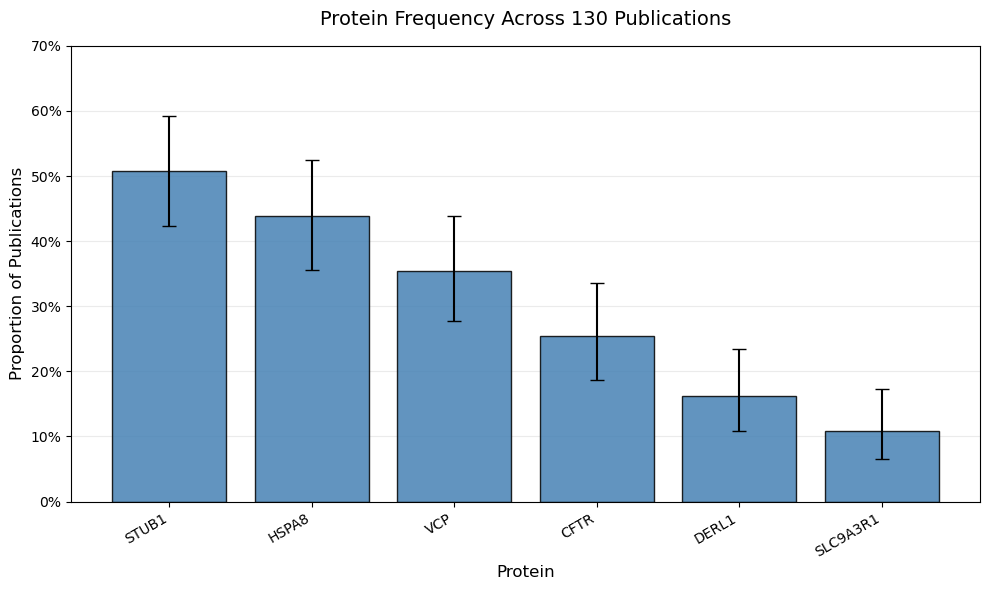

In [43]:

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Prepare data
x = frequency_summary["Proportion"]
lower_error = x - frequency_summary["CI_Lower"]
upper_error = frequency_summary["CI_Upper"] - x

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Bar chart
ax.bar(
    frequency_summary["Protein"],
    x,
    color="steelblue",
    edgecolor="black",
    alpha=0.85,
    width=0.8
)

# Add 95% Wilson confidence intervals
ax.errorbar(
    frequency_summary["Protein"],
    x,
    yerr=[lower_error, upper_error],
    fmt="none",
    ecolor="black",
    capsize=5,
    linewidth=1.5
)

# Titles and labels
ax.set_title(
    "Protein Frequency Across 130 Publications",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Protein", fontsize=12)
ax.set_ylabel("Proportion of Publications", fontsize=12)

# Format y-axis as percentages
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

# Set y-axis limits
ax.set_ylim(0, 0.7)

# Format x-axis labels
plt.xticks(rotation=30, ha="right")

# Add horizontal gridlines
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

# Adjust layout
plt.tight_layout()

# Display figure
plt.show()


In [44]:

# Count the number of selected proteins present in each publication
proteins_per_publication = publication_matrix[proteins].sum(axis=1)

# Summary statistics
print("Summary of proteins per publication:")
print(proteins_per_publication.describe())

# Frequency distribution
print("\nFrequency distribution:")
print(proteins_per_publication.value_counts().sort_index())


Summary of proteins per publication:
count    130.000000
mean       1.823077
std        0.730990
min        1.000000
25%        1.000000
50%        2.000000
75%        2.000000
max        5.000000
dtype: float64

Frequency distribution:
1    42
2    74
3    10
4     3
5     1
Name: count, dtype: int64


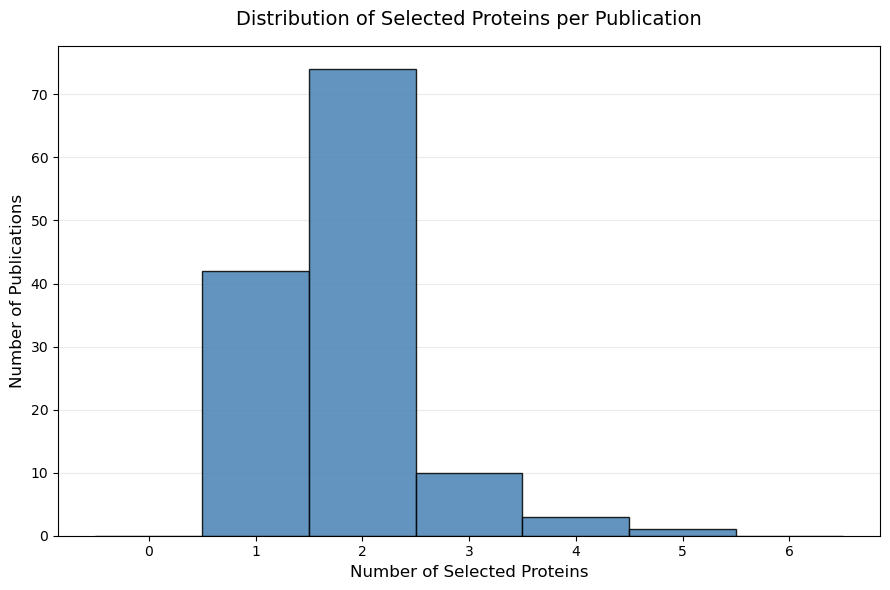

In [45]:

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 6))

bins = np.arange(-0.5, len(proteins) + 1.5, 1)

ax.hist(
    proteins_per_publication,
    bins=bins,
    color="steelblue",
    edgecolor="black",
    alpha=0.85
)

ax.set_title(
    "Distribution of Selected Proteins per Publication",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Number of Selected Proteins", fontsize=12)
ax.set_ylabel("Number of Publications", fontsize=12)

ax.set_xticks(range(len(proteins) + 1))
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


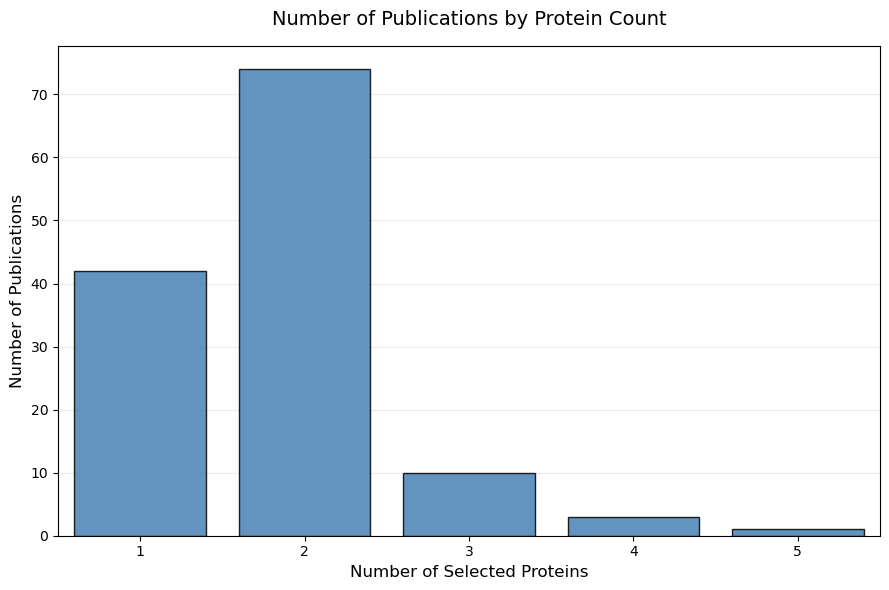

In [47]:

import matplotlib.pyplot as plt

# Calculate frequency distribution
protein_count_distribution = (
    proteins_per_publication
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.bar(
    protein_count_distribution.index,
    protein_count_distribution.values,
    color="steelblue",
    edgecolor="black",
    alpha=0.85,
    width=0.8
)

# Titles and labels
ax.set_title(
    "Number of Publications by Protein Count",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Number of Selected Proteins", fontsize=12)
ax.set_ylabel("Number of Publications", fontsize=12)

# Display only observed protein counts
ax.set_xticks(protein_count_distribution.index)
ax.set_xlim(0.5, 5.5)

# Add gridlines
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


In [152]:

import pandas as pd

# Define evidence configurations
evidence_conditions = {
    "No evidence": {},
    "CFTR = 1": {"CFTR": 1},
    "CFTR = 1, VCP = 1": {
        "CFTR": 1,
        "VCP": 1
    },
    "CFTR = 1, VCP = 1, HSPA8 = 1": {
        "CFTR": 1,
        "VCP": 1,
        "HSPA8": 1
    }
}

# Calculate conditional probabilities
conditional_results = []

for condition, evidence in evidence_conditions.items():

    result = expanded_inference.query(
        variables=["STUB1"],
        evidence=evidence,
        show_progress=False
    )

    probability = result.values[1]

    conditional_results.append({
        "Condition": condition,
        "P(STUB1 = 1)": probability
    })

conditional_summary = pd.DataFrame(conditional_results)

display(conditional_summary)


,Condition,P(STUB1 = 1)
0,No evidence,0.341071
1,CFTR = 1,0.156277
2,"CFTR = 1, VCP = 1",0.265171
3,"CFTR = 1, VCP = 1, HSPA8 = 1",0.355205


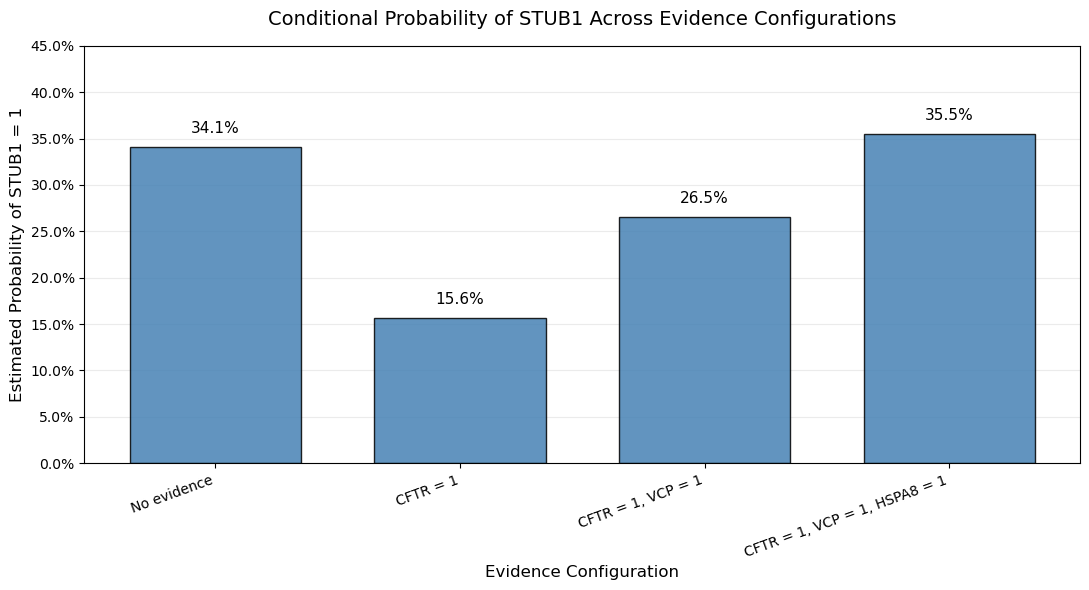

In [153]:

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    conditional_summary["Condition"],
    conditional_summary["P(STUB1 = 1)"],
    color="steelblue",
    edgecolor="black",
    alpha=0.85,
    width=0.7
)

# Add probability labels above each bar
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.012,
        f"{height:.1%}",
        ha="center",
        va="bottom",
        fontsize=11
    )

# Titles and labels
ax.set_title(
    "Conditional Probability of STUB1 Across Evidence Configurations",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Evidence Configuration", fontsize=12)
ax.set_ylabel("Estimated Probability of STUB1 = 1", fontsize=12)

# Format y-axis as percentages
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, 0.45)

# Improve readability
plt.xticks(rotation=20, ha="right")
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


In [154]:

import numpy as np
import pandas as pd

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination

# Settings
n_bootstrap = 500
rng = np.random.default_rng(42)

# Use the existing expanded dataset
bootstrap_data_source = (
    expanded_publication_matrix[expanded_proteins].copy()
)

# Define the evidence configurations
evidence_conditions = {
    "No evidence": {},
    "CFTR = 1": {"CFTR": 1},
    "CFTR = 1, VCP = 1": {
        "CFTR": 1,
        "VCP": 1
    },
    "CFTR = 1, VCP = 1, HSPA8 = 1": {
        "CFTR": 1,
        "VCP": 1,
        "HSPA8": 1
    }
}

# Store bootstrap estimates
bootstrap_results = {
    condition: []
    for condition in evidence_conditions
}

# Preserve both possible states for every protein
state_names = {
    protein: [0, 1]
    for protein in expanded_proteins
}

# Bootstrap procedure
for i in range(n_bootstrap):

    # Resample publication-level observations
    bootstrap_sample = bootstrap_data_source.sample(
        n=len(bootstrap_data_source),
        replace=True,
        random_state=int(rng.integers(0, 1_000_000))
    ).reset_index(drop=True)

    # Recreate the Bayesian network with the
    # original learned structure
    bootstrap_model = DiscreteBayesianNetwork(
        list(expanded_structure.edges())
    )

    bootstrap_model.add_nodes_from(expanded_proteins)

    # Re-estimate CPDs using BDeu
    bootstrap_model.fit(
        bootstrap_sample,
        estimator=BayesianEstimator,
        prior_type="BDeu",
        equivalent_sample_size=10,
        state_names=state_names
    )

    # Create inference engine
    bootstrap_inference = VariableElimination(
        bootstrap_model
    )

    # Calculate conditional probabilities
    for condition, evidence in evidence_conditions.items():

        result = bootstrap_inference.query(
            variables=["STUB1"],
            evidence=evidence,
            show_progress=False
        )

        bootstrap_results[condition].append(
            float(result.values[1])
        )

print("Bootstrap completed successfully.")


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSP

Bootstrap completed successfully.


In [155]:

# Calculate percentile confidence intervals
bootstrap_summary = []

for condition, estimates in bootstrap_results.items():

    estimates = np.asarray(estimates)

    bootstrap_summary.append({
        "Condition": condition,
        "Mean Estimate": estimates.mean(),
        "Bootstrap SD": estimates.std(ddof=1),
        "95% CI Lower": np.percentile(estimates, 2.5),
        "95% CI Upper": np.percentile(estimates, 97.5)
    })

bootstrap_summary = pd.DataFrame(bootstrap_summary)

# Format results as percentages
display(
    bootstrap_summary.style.format({
        "Mean Estimate": "{:.2%}",
        "Bootstrap SD": "{:.2%}",
        "95% CI Lower": "{:.2%}",
        "95% CI Upper": "{:.2%}"
    })
)


,Condition,Mean Estimate,Bootstrap SD,95% CI Lower,95% CI Upper
0,No evidence,34.12%,1.14%,31.89%,36.35%
1,CFTR = 1,16.38%,4.05%,8.78%,24.44%
2,"CFTR = 1, VCP = 1",30.52%,14.83%,8.96%,66.70%
3,"CFTR = 1, VCP = 1, HSPA8 = 1",36.37%,20.42%,8.30%,80.84%


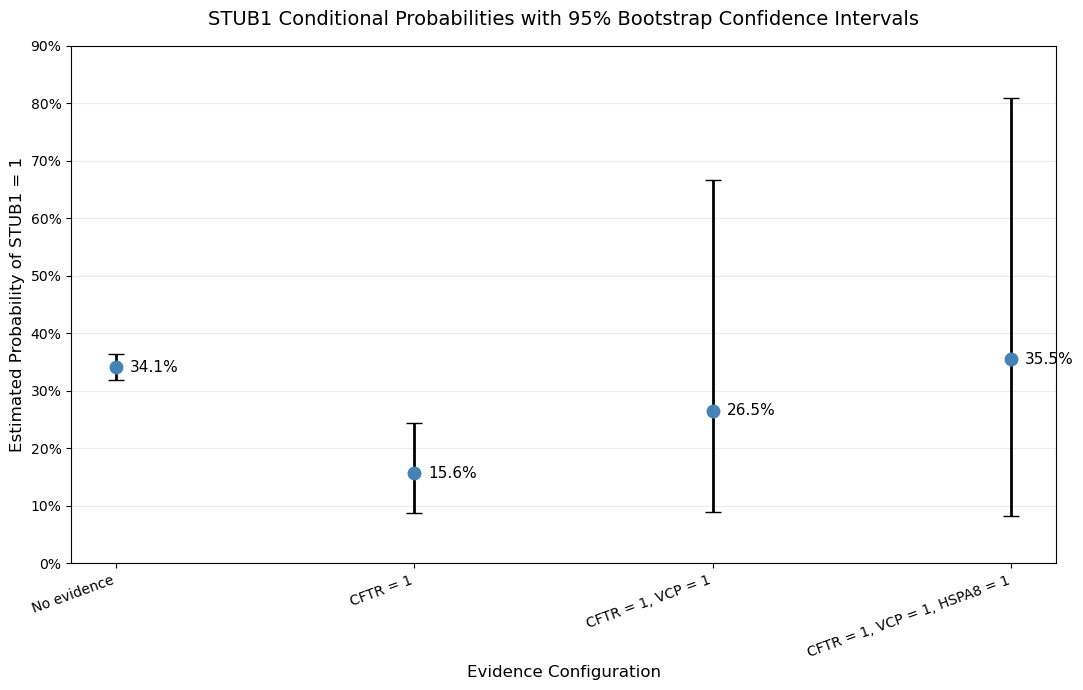

In [157]:

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np

# Original model estimates
original_estimates = conditional_summary[
    "P(STUB1 = 1)"
].to_numpy()

# Bootstrap confidence interval bounds
lower_bounds = bootstrap_summary[
    "95% CI Lower"
].to_numpy()

upper_bounds = bootstrap_summary[
    "95% CI Upper"
].to_numpy()

# Calculate asymmetric error bars
lower_error = original_estimates - lower_bounds
upper_error = upper_bounds - original_estimates

x_positions = np.arange(len(original_estimates))

fig, ax = plt.subplots(figsize=(11, 7))

# Plot estimates and confidence intervals
ax.errorbar(
    x_positions,
    original_estimates,
    yerr=[lower_error, upper_error],
    fmt="o",
    color="steelblue",
    ecolor="black",
    capsize=6,
    markersize=9,
    linewidth=2
)

# Label the original point estimates
for i, estimate in enumerate(original_estimates):
    ax.annotate(
        f"{estimate:.1%}",
        (x_positions[i], estimate),
        xytext=(10, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=11
    )

# X-axis labels
ax.set_xticks(x_positions)
ax.set_xticklabels(
    conditional_summary["Condition"],
    rotation=20,
    ha="right"
)

# Titles and axis labels
ax.set_title(
    "STUB1 Conditional Probabilities with 95% Bootstrap Confidence Intervals",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Evidence Configuration", fontsize=12)
ax.set_ylabel("Estimated Probability of STUB1 = 1", fontsize=12)

# Format y-axis as percentages
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

# Expand the y-axis to include the full confidence intervals
ax.set_ylim(0, 0.90)

# Gridlines
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


In [158]:

# Count observations supporting each evidence configuration

support_conditions = {
    "No evidence": [],
    "CFTR = 1": ["CFTR"],
    "CFTR = 1, VCP = 1": ["CFTR", "VCP"],
    "CFTR = 1, VCP = 1, HSPA8 = 1": [
        "CFTR", "VCP", "HSPA8"
    ]
}

support_results = []

for condition, variables in support_conditions.items():

    if len(variables) == 0:
        count = len(bootstrap_data_source)
    else:
        count = (
            bootstrap_data_source[variables]
            .eq(1)
            .all(axis=1)
            .sum()
        )

    support_results.append({
        "Evidence Configuration": condition,
        "Supporting Publications": int(count),
        "Percentage of Dataset": count / len(bootstrap_data_source)
    })

support_summary = pd.DataFrame(support_results)

display(
    support_summary.style.format({
        "Percentage of Dataset": "{:.2%}"
    })
)


,Evidence Configuration,Supporting Publications,Percentage of Dataset
0,No evidence,1668,100.00%
1,CFTR = 1,84,5.04%
2,"CFTR = 1, VCP = 1",11,0.66%
3,"CFTR = 1, VCP = 1, HSPA8 = 1",7,0.42%


In [70]:
expanded_proteins_per_publication = (
    expanded_publication_matrix[expanded_proteins]
    .sum(axis=1)
)

print(expanded_proteins_per_publication.describe())

count    1668.000000
mean        1.416067
std         0.879429
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         9.000000
dtype: float64


In [71]:
protein_count_distribution = (
    expanded_proteins_per_publication
    .value_counts()
    .sort_index()
)

display(protein_count_distribution)

1    1210
2     320
3      92
4      23
5      10
6       6
8       5
9       2
Name: count, dtype: int64

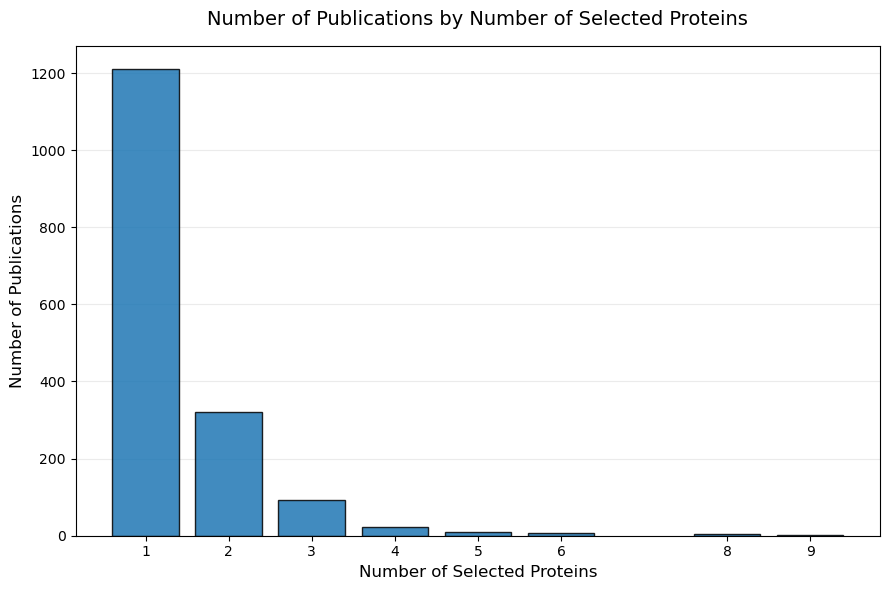

In [72]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))

ax.bar(
    protein_count_distribution.index,
    protein_count_distribution.values,
    edgecolor="black",
    alpha=0.85,
    width=0.8
)

ax.set_title(
    "Number of Publications by Number of Selected Proteins",
    fontsize=14,
    pad=15
)
ax.set_xlabel("Number of Selected Proteins", fontsize=12)
ax.set_ylabel("Number of Publications", fontsize=12)

ax.set_xticks(protein_count_distribution.index)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [69]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportion_confint

# Expanded dataset
n = len(expanded_publication_matrix)

# Calculate protein frequencies
expanded_frequencies = (
    expanded_publication_matrix[expanded_proteins]
    .sum()
    .sort_values(ascending=False)
)

# Calculate proportions
expanded_proportions = expanded_frequencies / n

# Calculate 95% Wilson confidence intervals
ci_lower = []
ci_upper = []

for count in expanded_frequencies:
    lower, upper = proportion_confint(
        count,
        n,
        alpha=0.05,
        method="wilson"
    )
    ci_lower.append(lower)
    ci_upper.append(upper)

# Create summary table
expanded_frequency_summary = pd.DataFrame({
    "Protein": expanded_frequencies.index,
    "Publications": expanded_frequencies.values,
    "Proportion": expanded_proportions.values,
    "CI_Lower": ci_lower,
    "CI_Upper": ci_upper
})

display(
    expanded_frequency_summary.style.format({
        "Proportion": "{:.2%}",
        "CI_Lower": "{:.2%}",
        "CI_Upper": "{:.2%}"
    })
)

,Protein,Publications,Proportion,CI_Lower,CI_Upper
0,HSPA8,722,43.29%,40.93%,45.68%
1,VCP,596,35.73%,33.47%,38.06%
2,STUB1,560,33.57%,31.35%,35.87%
3,SLC9A3R1,114,6.83%,5.72%,8.15%
4,DERL1,113,6.77%,5.67%,8.08%
5,CFTR,84,5.04%,4.09%,6.19%
6,HSPA4,80,4.80%,3.87%,5.93%
7,HSP90AA1,57,3.42%,2.65%,4.40%
8,DNAJA1,14,0.84%,0.50%,1.40%
9,HSPB1,11,0.66%,0.37%,1.18%


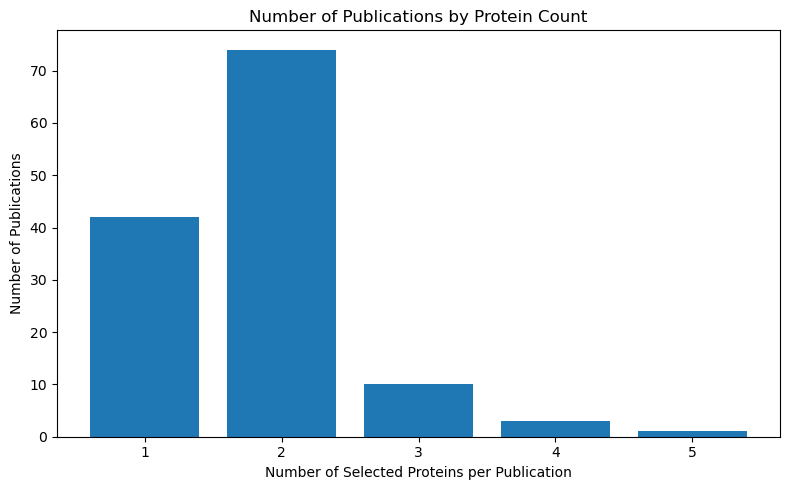

In [73]:
import matplotlib.pyplot as plt

# Number of selected proteins represented per publication
protein_counts = {
    1: 42,
    2: 74,
    3: 10,
    4: 3,
    5: 1
}

# Create bar chart
plt.figure(figsize=(8, 5))

plt.bar(
    protein_counts.keys(),
    protein_counts.values()
)

plt.xlabel("Number of Selected Proteins per Publication")
plt.ylabel("Number of Publications")
plt.title("Number of Publications by Protein Count")

# Make sure all observed counts are shown
plt.xticks(range(1, 6))

plt.tight_layout()
plt.show()

In [79]:
import numpy as np
import pandas as pd

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination

# --------------------------------------------------
# Bootstrap settings
# --------------------------------------------------

n_bootstrap = 500
rng = np.random.default_rng(42)

# Store bootstrap estimates for the four CFTR queries
bootstrap_results = {
    "No evidence": [],
    "HSPA8 = 1": [],
    "VCP = 1": [],
    "HSPA8 = 1, VCP = 1": []
}

# --------------------------------------------------
# Bootstrap procedure
# --------------------------------------------------

for i in range(n_bootstrap):

    # Resample publication-level observations
    bootstrap_data = (
        expanded_publication_matrix[expanded_proteins]
        .sample(
            n=len(expanded_publication_matrix),
            replace=True,
            random_state=int(rng.integers(0, 1_000_000))
        )
        .reset_index(drop=True)
    )

    # Keep the previously learned network structure fixed
    bootstrap_model = DiscreteBayesianNetwork(
        list(expanded_structure.edges())
    )

    # Re-estimate CPDs using the same BDeu settings
    bootstrap_model.fit(
        bootstrap_data,
        estimator=BayesianEstimator,
        prior_type="BDeu",
        equivalent_sample_size=10
    )

    # Perform inference
    bootstrap_inference = VariableElimination(bootstrap_model)

    # --------------------------------------------------
    # Query 1: P(CFTR = 1)
    # --------------------------------------------------

    result = bootstrap_inference.query(
        variables=["CFTR"]
    )

    bootstrap_results["No evidence"].append(
        result.values[1]
    )

    # --------------------------------------------------
    # Query 2: P(CFTR = 1 | HSPA8 = 1)
    # --------------------------------------------------

    result = bootstrap_inference.query(
        variables=["CFTR"],
        evidence={"HSPA8": 1}
    )

    bootstrap_results["HSPA8 = 1"].append(
        result.values[1]
    )

    # --------------------------------------------------
    # Query 3: P(CFTR = 1 | VCP = 1)
    # --------------------------------------------------

    result = bootstrap_inference.query(
        variables=["CFTR"],
        evidence={"VCP": 1}
    )

    bootstrap_results["VCP = 1"].append(
        result.values[1]
    )

    # --------------------------------------------------
    # Query 4: P(CFTR = 1 | HSPA8 = 1, VCP = 1)
    # --------------------------------------------------

    result = bootstrap_inference.query(
        variables=["CFTR"],
        evidence={
            "HSPA8": 1,
            "VCP": 1
        }
    )

    bootstrap_results["HSPA8 = 1, VCP = 1"].append(
        result.values[1]
    )

# --------------------------------------------------
# Summarize bootstrap results
# --------------------------------------------------

bootstrap_summary = []

for condition, values in bootstrap_results.items():

    values = np.array(values)

    bootstrap_summary.append({
        "Condition": condition,
        "Mean Estimate": values.mean(),
        "Bootstrap SD": values.std(ddof=1),
        "95% CI Lower": np.percentile(values, 2.5),
        "95% CI Upper": np.percentile(values, 97.5)
    })

bootstrap_summary = pd.DataFrame(bootstrap_summary)

display(
    bootstrap_summary.style.format({
        "Mean Estimate": "{:.2%}",
        "Bootstrap SD": "{:.2%}",
        "95% CI Lower": "{:.2%}",
        "95% CI Upper": "{:.2%}"
    })
)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSP

,Condition,Mean Estimate,Bootstrap SD,95% CI Lower,95% CI Upper
0,No evidence,5.28%,0.55%,4.16%,6.27%
1,HSPA8 = 1,2.66%,0.54%,1.64%,3.74%
2,VCP = 1,2.25%,0.54%,1.34%,3.31%
3,"HSPA8 = 1, VCP = 1",4.39%,1.32%,2.17%,7.29%


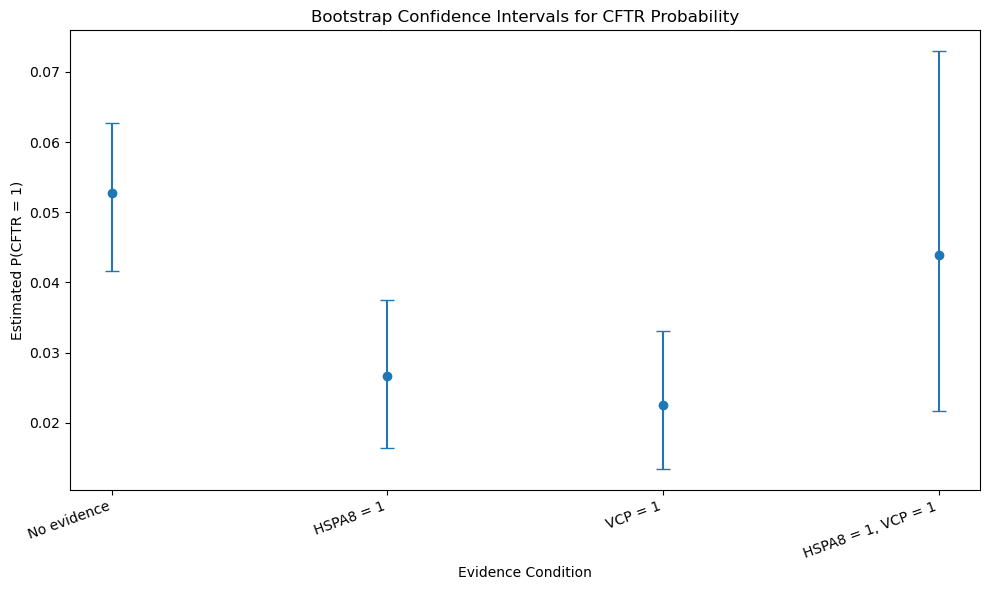

In [80]:
import matplotlib.pyplot as plt
import numpy as np

conditions = bootstrap_summary["Condition"]

estimates = bootstrap_summary["Mean Estimate"].values
lower = bootstrap_summary["95% CI Lower"].values
upper = bootstrap_summary["95% CI Upper"].values

# Distance from the mean estimate to each CI endpoint
lower_error = estimates - lower
upper_error = upper - estimates

x = np.arange(len(conditions))

plt.figure(figsize=(10, 6))

plt.errorbar(
    x,
    estimates,
    yerr=[lower_error, upper_error],
    fmt='o',
    capsize=5
)

plt.xticks(
    x,
    conditions,
    rotation=20,
    ha="right"
)

plt.ylabel("Estimated P(CFTR = 1)")
plt.xlabel("Evidence Condition")
plt.title("Bootstrap Confidence Intervals for CFTR Probability")

plt.tight_layout()
plt.show()

In [81]:
# Create a LaTeX table from the bootstrap results

latex_table = bootstrap_summary.copy()

# Format values as percentages
for column in [
    "Mean Estimate",
    "Bootstrap SD",
    "95% CI Lower",
    "95% CI Upper"
]:
    latex_table[column] = latex_table[column].map(
        lambda x: f"{x:.2%}"
    )

# Rename columns for the thesis
latex_table = latex_table.rename(columns={
    "Mean Estimate": "Mean Estimate",
    "Bootstrap SD": "Bootstrap SD",
    "95% CI Lower": "95\% CI Lower",
    "95% CI Upper": "95\% CI Upper"
})

# Generate LaTeX
print(
    latex_table.to_latex(
        index=False,
        escape=False
    )
)

\begin{tabular}{lllll}
\toprule
Condition & Mean Estimate & Bootstrap SD & 95\% CI Lower & 95\% CI Upper \\
\midrule
No evidence & 5.28% & 0.55% & 4.16% & 6.27% \\
HSPA8 = 1 & 2.66% & 0.54% & 1.64% & 3.74% \\
VCP = 1 & 2.25% & 0.54% & 1.34% & 3.31% \\
HSPA8 = 1, VCP = 1 & 4.39% & 1.32% & 2.17% & 7.29% \\
\bottomrule
\end{tabular}



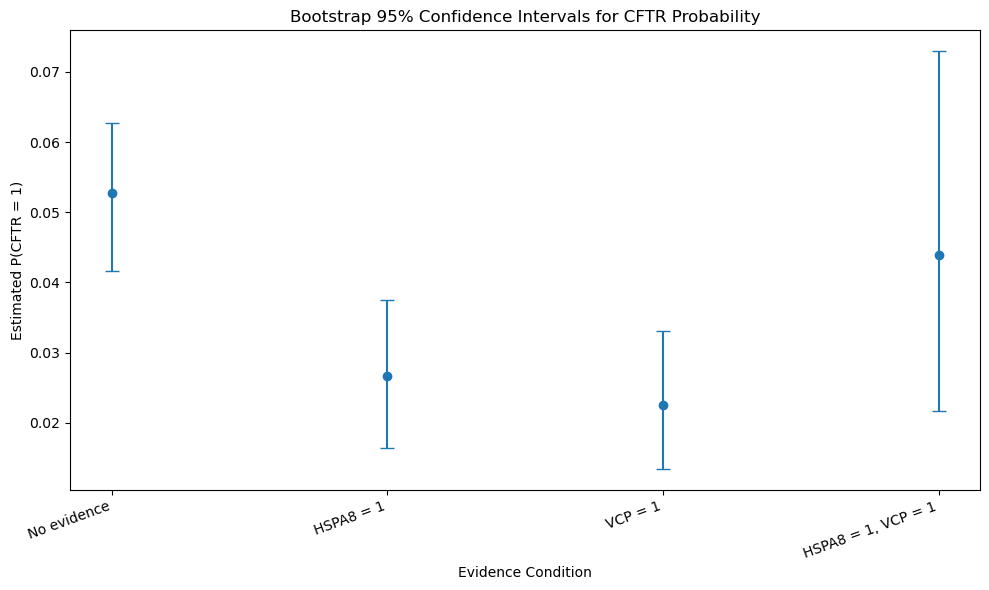

In [82]:
import matplotlib.pyplot as plt
import numpy as np

conditions = bootstrap_summary["Condition"]

estimates = bootstrap_summary["Mean Estimate"].values
lower = bootstrap_summary["95% CI Lower"].values
upper = bootstrap_summary["95% CI Upper"].values

# Calculate the distance from the mean to each confidence-limit endpoint
lower_error = estimates - lower
upper_error = upper - estimates

x = np.arange(len(conditions))

plt.figure(figsize=(10, 6))

plt.errorbar(
    x,
    estimates,
    yerr=[lower_error, upper_error],
    fmt='o',
    capsize=5
)

plt.xticks(
    x,
    conditions,
    rotation=20,
    ha="right"
)

plt.ylabel("Estimated P(CFTR = 1)")
plt.xlabel("Evidence Condition")
plt.title("Bootstrap 95% Confidence Intervals for CFTR Probability")

plt.tight_layout()
plt.show()

In [83]:
support_counts = {
    "No evidence": len(expanded_publication_matrix),
    "HSPA8 = 1": (expanded_publication_matrix["HSPA8"] == 1).sum(),
    "VCP = 1": (expanded_publication_matrix["VCP"] == 1).sum(),
    "HSPA8 = 1, VCP = 1": (
        (expanded_publication_matrix["HSPA8"] == 1) &
        (expanded_publication_matrix["VCP"] == 1)
    ).sum()
}

support_counts

{'No evidence': 1668,
 'HSPA8 = 1': np.int64(722),
 'VCP = 1': np.int64(596),
 'HSPA8 = 1, VCP = 1': np.int64(187)}

In [85]:
# Create a publication-level binary dataset

publication_protein_data = []

for publication, group in candidate_edges.groupby("Publication Source"):
    
    row = {"Publication": publication}
    
    for protein in proteins:
        present = (
            (group["Official Symbol Interactor A"] == protein) |
            (group["Official Symbol Interactor B"] == protein)
        ).any()
        
        row[protein] = int(present)
    
    publication_protein_data.append(row)

publication_matrix = pd.DataFrame(publication_protein_data)

print("Number of observations:", len(publication_matrix))
print("Number of protein variables:", len(proteins))

display(publication_matrix.head(20))

Number of observations: 130
Number of protein variables: 6


,Publication,CFTR,HSPA8,SLC9A3R1,VCP,STUB1,DERL1
0,PUBMED:10075921,1,1,0,0,0,0
1,PUBMED:10330192,0,1,0,0,1,0
2,PUBMED:10350210,0,0,0,1,0,0
3,PUBMED:10666020,1,1,0,0,0,0
4,PUBMED:10852925,1,0,1,0,0,0
5,PUBMED:10982807,1,1,0,0,0,0
6,PUBMED:11046132,0,0,1,0,0,0
7,PUBMED:11051556,1,0,0,0,0,0
8,PUBMED:11146634,1,1,0,0,1,0
9,PUBMED:11533036,0,0,1,0,0,0


In [116]:
# ---------------------------------------------------------
# Create exactly 240 feature sets
# 40 runs for each feature count: 6, 7, 8, 9, 10, 11
# ---------------------------------------------------------

rng = np.random.default_rng(2026)

required_proteins = [
    "CFTR",
    "HSPA8",
    "VCP"
]

optional_proteins = [
    protein
    for protein in expanded_proteins
    if protein not in required_proteins
]

feature_sets = []

for number_of_proteins in range(6, 12):

    number_optional = number_of_proteins - len(required_proteins)

    # Generate 40 feature sets.
    for i in range(40):

        selected_optional = rng.choice(
            optional_proteins,
            size=number_optional,
            replace=False
        ).tolist()

        selected_proteins = tuple(
            required_proteins + sorted(selected_optional)
        )

        feature_sets.append(selected_proteins)

# ---------------------------------------------------------
# Verify
# ---------------------------------------------------------

print("Total feature sets:", len(feature_sets))

print("\nFeature sets by number of proteins:")

print(
    pd.Series(
        [len(features) for features in feature_sets]
    ).value_counts().sort_index()
)

Total feature sets: 240

Feature sets by number of proteins:
6     40
7     40
8     40
9     40
10    40
11    40
Name: count, dtype: int64


In [117]:
import numpy as np
import pandas as pd

from pgmpy.estimators import HillClimbSearch, BIC, BayesianEstimator
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination
from pgmpy.factors.discrete import TabularCPD

# ---------------------------------------------------------
# Repeated full-method assessment
# 240 runs
# Feature variation + bootstrap resampling
# ---------------------------------------------------------

n_runs = 240

# Reproducible random number generator
rng = np.random.default_rng(2026)

# ---------------------------------------------------------
# Proteins kept in every run
# ---------------------------------------------------------

required_proteins = [
    "CFTR",
    "HSPA8",
    "VCP"
]

# Remaining proteins available for feature selection
optional_proteins = [
    protein
    for protein in expanded_proteins
    if protein not in required_proteins
]

# ---------------------------------------------------------
# Check the feature sets
# ---------------------------------------------------------

print("Number of feature sets:", len(feature_sets))

# ---------------------------------------------------------
# Run the complete method 240 times
# ---------------------------------------------------------

repeated_results = []

for run_number, selected_proteins in enumerate(
    feature_sets,
    start=1
):

    print(f"Run {run_number} of {len(feature_sets)}")

    # -----------------------------------------------------
    # Bootstrap resample the publication-level observations
    # -----------------------------------------------------

    bootstrap_indices = rng.choice(
        expanded_publication_matrix.index,
        size=len(expanded_publication_matrix),
        replace=True
    )

    run_data = expanded_publication_matrix.loc[
        bootstrap_indices,
        list(selected_proteins)
    ].reset_index(drop=True)

    # -----------------------------------------------------
    # Structure learning
    # -----------------------------------------------------

    run_estimator = HillClimbSearch(run_data)

    run_structure = run_estimator.estimate(
        scoring_method=BIC(run_data),
        show_progress=False
    )

    # -----------------------------------------------------
    # Calculate BIC
    # -----------------------------------------------------

    run_bic = BIC(run_data).score(run_structure)

    # -----------------------------------------------------
    # Create Bayesian network
    # -----------------------------------------------------

    run_pgm = DiscreteBayesianNetwork()

    # Add all selected proteins
    run_pgm.add_nodes_from(selected_proteins)

    # Add learned edges
    run_pgm.add_edges_from(
        run_structure.edges()
    )

    # -----------------------------------------------------
    # Parameter estimation using BDeu
    # -----------------------------------------------------

    state_names = {
        protein: [0, 1]
        for protein in selected_proteins
    }

    run_pgm.fit(
        run_data,
        estimator=BayesianEstimator,
        prior_type="BDeu",
        equivalent_sample_size=10,
        state_names=state_names
    )

    # -----------------------------------------------------
    # Add CPDs manually for isolated nodes if pgmpy
    # does not create them automatically.
    #
    # For an isolated binary node with BDeu ESS = 10:
    #
    # P(X=x) = (N_x + 5) / (N + 10)
    #
    # because alpha = 10 and there are two states.
    # -----------------------------------------------------

    existing_cpds = {
        cpd.variable
        for cpd in run_pgm.get_cpds()
    }

    for protein in selected_proteins:

        if protein not in existing_cpds:

            count_0 = (
                run_data[protein] == 0
            ).sum()

            count_1 = (
                run_data[protein] == 1
            ).sum()

            n = len(run_data)

            p0 = (count_0 + 5) / (n + 10)
            p1 = (count_1 + 5) / (n + 10)

            isolated_cpd = TabularCPD(
                variable=protein,
                variable_card=2,
                values=[
                    [p0],
                    [p1]
                ],
                state_names={
                    protein: [0, 1]
                }
            )

            run_pgm.add_cpds(isolated_cpd)

    # -----------------------------------------------------
    # Probabilistic inference
    # -----------------------------------------------------

    run_inference = VariableElimination(run_pgm)

    # -----------------------------------------------------
    # P(CFTR = 1)
    # -----------------------------------------------------

    p_cftr = float(
        run_inference.query(
            variables=["CFTR"],
            show_progress=False
        ).values[1]
    )

    # -----------------------------------------------------
    # P(CFTR = 1 | HSPA8 = 1)
    # -----------------------------------------------------

    p_cftr_hspa8 = float(
        run_inference.query(
            variables=["CFTR"],
            evidence={"HSPA8": 1},
            show_progress=False
        ).values[1]
    )

    # -----------------------------------------------------
    # P(CFTR = 1 | VCP = 1)
    # -----------------------------------------------------

    p_cftr_vcp = float(
        run_inference.query(
            variables=["CFTR"],
            evidence={"VCP": 1},
            show_progress=False
        ).values[1]
    )

    # -----------------------------------------------------
    # P(CFTR = 1 | HSPA8 = 1, VCP = 1)
    # -----------------------------------------------------

    p_cftr_hspa8_vcp = float(
        run_inference.query(
            variables=["CFTR"],
            evidence={
                "HSPA8": 1,
                "VCP": 1
            },
            show_progress=False
        ).values[1]
    )

    # -----------------------------------------------------
    # Store results
    # -----------------------------------------------------

    repeated_results.append({
        "Run": run_number,
        "Number_of_Proteins": len(selected_proteins),
        "Proteins": ", ".join(selected_proteins),
        "Number_of_Edges": len(run_structure.edges()),
        "BIC": run_bic,
        "P_CFTR": p_cftr,
        "P_CFTR_HSPA8": p_cftr_hspa8,
        "P_CFTR_VCP": p_cftr_vcp,
        "P_CFTR_HSPA8_VCP": p_cftr_hspa8_vcp,
        "Edges": list(run_structure.edges())
    })

print("\nRepeated method assessment completed.")

# ---------------------------------------------------------
# Convert results to DataFrame
# ---------------------------------------------------------

repeated_results_df = pd.DataFrame(
    repeated_results
)

# ---------------------------------------------------------
# Verify all runs completed
# ---------------------------------------------------------

print(
    "\nTotal completed runs:",
    len(repeated_results_df)
)

print("\nRuns by number of proteins:")

print(
    repeated_results_df[
        "Number_of_Proteins"
    ].value_counts().sort_index()
)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'DNAJA1': 'N', 'SLC9A3R1': 'N', 'STUB1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'DNAJA1': 'N', 'SLC9A3R1': 'N', 'STUB1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'DNAJA1': 'N', 'SLC9A3R1': 'N', 'STUB1': 'N'}


Number of feature sets: 240
Run 1 of 240


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'DNAJA1': 'N', 'SLC9A3R1': 'N', 'STUB1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'DNAJA1': 'N', 'SLC9A3R1': 'N', 'STUB1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'CANX': 'N', 'DERL1': 'N', 'SLC9A3R1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'CANX': 'N', 'DERL1': 'N', 'SLC9A3R1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'CANX': 'N', 'DERL1': 'N', 'SLC9A3R1': 'N'}


Run 2 of 240


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'CANX': 'N', 'DERL1': 'N', 'SLC9A3R1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'CANX': 'N', 'DERL1': 'N', 'SLC9A3R1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'CANX': 'N', 'DNAJA1': 'N', 'HSPA4': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'CANX': 'N', 'DNAJA1': 'N', 'HSPA4': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'CANX': 'N', 'DNAJA1': 'N', 'HSPA4': 'N'}


...

Run 239 of 240


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'CANX': 'N', 'DERL1': 'N', 'DNAJA1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'HSPB1': 'N', 'SLC9A3R1': 'N', 'STUB1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'CANX': 'N', 'DERL1': 'N', 'DNAJA1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'HSPB1': 'N', 'SLC9A3R1': 'N', 'STUB1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'CANX': 'N', 'DERL1': 'N', 'DNAJA1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'HSPB1': 'N', 'SLC9A3R1': 'N', 'STUB1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'CANX': 'N', 'DERL1': 'N', 'DNAJA1': 'N', 'HSP90AA1': 'N', 'HSPA4'

Run 240 of 240


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'CANX': 'N', 'DERL1': 'N', 'DNAJA1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'HSPB1': 'N', 'SLC9A3R1': 'N', 'STUB1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'CANX': 'N', 'DERL1': 'N', 'DNAJA1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'HSPB1': 'N', 'SLC9A3R1': 'N', 'STUB1': 'N'}



Repeated method assessment completed.

Total completed runs: 240

Runs by number of proteins:
Number_of_Proteins
6     40
7     40
8     40
9     40
10    40
11    40
Name: count, dtype: int64


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'CANX': 'N', 'DNAJA1': 'N', 'SLC9A3R1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'CANX': 'N', 'DNAJA1': 'N', 'SLC9A3R1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'CANX': 'N', 'DNAJA1': 'N', 'SLC9A3R1': 'N'}


Run 1 of 240


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'CANX': 'N', 'DNAJA1': 'N', 'SLC9A3R1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'CANX': 'N', 'DNAJA1': 'N', 'SLC9A3R1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'DNAJA1': 'N', 'HSP90AA1': 'N', 'HSPB1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'DNAJA1': 'N', 'HSP90AA1': 'N', 'HSPB1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'DNAJA1': 'N', 'HSP90AA1': 'N', 'HSPB1': 'N'}


Run 2 of 240


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'DNAJA1': 'N', 'HSP90AA1': 'N', 'HSPB1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'DNAJA1': 'N', 'HSP90AA1': 'N', 'HSPB1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'STUB1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'STUB1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'STUB1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical

...

Run 99 of 240


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'CANX': 'N', 'DNAJA1': 'N', 'HSPA4': 'N', 'SLC9A3R1': 'N', 'STUB1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'CANX': 'N', 'DNAJA1': 'N', 'HSPA4': 'N', 'SLC9A3R1': 'N', 'STUB1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'CANX': 'N', 'DNAJA1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'STUB1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'CANX': 'N', 'DNAJA1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'STUB1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 

Run 100 of 240


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'CANX': 'N', 'DNAJA1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'STUB1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'VCP': 'N', 'CANX': 'N', 'DNAJA1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'STUB1': 'N'}


KeyboardInterrupt: 

In [118]:
repeated_results_df = pd.DataFrame(repeated_results)

display(repeated_results_df.head(10))

,Run,Number_of_Proteins,Proteins,Number_of_Edges,BIC,P_CFTR,P_CFTR_HSPA8,P_CFTR_VCP,P_CFTR_HSPA8_VCP,Edges
0,1,6,"CFTR, HSPA8, VCP, DNAJA1, SLC9A3R1, STUB1",11,-3601.529045,0.057807,0.021648,0.019862,0.039726,"[(CFTR, STUB1), (CFTR, VCP), (CFTR, HSPA8), (H..."
1,2,6,"CFTR, HSPA8, VCP, CANX, DERL1, SLC9A3R1",9,-3371.008981,0.054827,0.051273,0.022093,0.050188,"[(CFTR, VCP), (CFTR, SLC9A3R1), (HSPA8, VCP), ..."
2,3,6,"CFTR, HSPA8, VCP, CANX, DNAJA1, HSPA4",7,-2954.884565,0.055844,0.033207,0.036308,0.058473,"[(HSPA8, VCP), (HSPA8, CFTR), (VCP, CFTR), (CA..."
3,4,6,"CFTR, HSPA8, VCP, DNAJA1, HSPB1, STUB1",9,-3446.357003,0.056615,0.021417,0.025308,0.048926,"[(CFTR, STUB1), (HSPA8, STUB1), (HSPA8, CFTR),..."
4,5,6,"CFTR, HSPA8, VCP, DNAJA1, HSPB1, SLC9A3R1",7,-2989.072675,0.049294,0.027974,0.018608,0.040342,"[(HSPA8, CFTR), (VCP, HSPA8), (VCP, CFTR), (DN..."
5,6,6,"CFTR, HSPA8, VCP, HSP90AA1, HSPA4, HSPB1",7,-3041.858892,0.050541,0.019974,0.015534,0.032300,"[(HSPA8, VCP), (HSPA8, CFTR), (VCP, CFTR), (VC..."
6,7,6,"CFTR, HSPA8, VCP, CANX, DNAJA1, HSP90AA1",7,-2860.745589,0.045292,0.023810,0.018608,0.039379,"[(CFTR, VCP), (CFTR, HSPA8), (HSPA8, VCP), (HS..."
7,8,6,"CFTR, HSPA8, VCP, CANX, DERL1, STUB1",8,-3597.080753,0.045888,0.045888,0.019022,0.050171,"[(CFTR, VCP), (HSPA8, VCP), (HSPA8, CANX), (VC..."
8,9,6,"CFTR, HSPA8, VCP, DNAJA1, HSP90AA1, SLC9A3R1",8,-3200.777376,0.057807,0.033571,0.017749,0.043926,"[(CFTR, VCP), (CFTR, SLC9A3R1), (HSPA8, VCP), ..."
9,10,6,"CFTR, HSPA8, VCP, DNAJA1, HSP90AA1, SLC9A3R1",8,-3143.943983,0.047080,0.011553,0.016263,0.015870,"[(CFTR, HSPA8), (CFTR, VCP), (VCP, HSPA8), (VC..."


In [119]:
probability_columns = [
    "P_CFTR",
    "P_CFTR_HSPA8",
    "P_CFTR_VCP",
    "P_CFTR_HSPA8_VCP"
]

repeated_summary = pd.DataFrame({
    "Mean": repeated_results_df[
        probability_columns
    ].mean(),

    "SD": repeated_results_df[
        probability_columns
    ].std(),

    "Lower_95": repeated_results_df[
        probability_columns
    ].quantile(0.025),

    "Upper_95": repeated_results_df[
        probability_columns
    ].quantile(0.975),

    "Minimum": repeated_results_df[
        probability_columns
    ].min(),

    "Maximum": repeated_results_df[
        probability_columns
    ].max()
})

display(repeated_summary)

,Mean,SD,Lower_95,Upper_95,Minimum,Maximum
P_CFTR,0.052944,0.005330,0.043495,0.063776,0.038631,0.069726
P_CFTR_HSPA8,0.029219,0.009940,0.017691,0.057719,0.011553,0.064295
P_CFTR_VCP,0.022336,0.006987,0.012158,0.036386,0.009154,0.060763
P_CFTR_HSPA8_VCP,0.039711,0.014706,0.016663,0.073580,0.007706,0.087622


In [120]:
results_by_features = (
    repeated_results_df
    .groupby("Number_of_Proteins")
    .agg({
        "Run": "count",
        "Number_of_Edges": ["mean", "std"],
        "BIC": ["mean", "std"],
        "P_CFTR": ["mean", "std"],
        "P_CFTR_HSPA8": ["mean", "std"],
        "P_CFTR_VCP": ["mean", "std"],
        "P_CFTR_HSPA8_VCP": ["mean", "std"]
    })
)

display(results_by_features)

Run Number_of_Edges                    BIC              \
                   count            mean       std         mean         std   
Number_of_Proteins                                                            
6                     40           8.650  1.251666 -3266.662106  244.224821   
7                     40          11.125  1.324087 -3615.021793  295.512230   
8                     40          12.775  1.609069 -3798.329413  282.285184   
9                     40          16.275  1.853444 -4121.681712  213.456329   
10                    40          18.300  1.343551 -4329.206218  145.388301   
11                    40          20.800  1.362501 -4481.330352   61.425194   

                      P_CFTR           P_CFTR_HSPA8           P_CFTR_VCP  \
                        mean       std         mean       std       mean   
Number_of_Proteins                                                         
6                   0.052428  0.006647     0.030424  0.011294   0.021471   
7                   0.052963  0.004636     0.029611  0.010177   0.022581   
8                   0.052219  0.005323     0.026527  0.005665   0.024247   
9                   0.052840  0.004616     0.031156  0.011883   0.022852   
10                  0.054287  0.004855     0.027761  0.007841   0.022076   
11                  0.052925  0.005706     0.029836  0.011140   0.020788   

                             P_CFTR_HSPA8_VCP            
                         std             mean       std  
Number_of_Proteins                                       
6                   0.005461         0.041084  0.014991  
7                   0.005680         0.042389  0.017008  
8                   0.009979         0.041364  0.014223  
9                   0.007828         0.037531  0.013275  
10                  0.006312         0.038696  0.013974  
11                  0.005384         0.037204  0.014594

In [121]:
print("Total completed runs:", len(repeated_results_df))

print("\nRuns by number of proteins:")
print(
    repeated_results_df["Number_of_Proteins"]
    .value_counts()
    .sort_index()
)

Total completed runs: 240

Runs by number of proteins:
Number_of_Proteins
6     40
7     40
8     40
9     40
10    40
11    40
Name: count, dtype: int64


In [122]:
print("Number of feature sets:", len(feature_sets))

print("\nFeature sets by number of proteins:")

print(
    pd.Series(
        [len(features) for features in feature_sets]
    ).value_counts().sort_index()
)

Number of feature sets: 240

Feature sets by number of proteins:
6     40
7     40
8     40
9     40
10    40
11    40
Name: count, dtype: int64


In [127]:
# Edge Stability Analysis

from collections import defaultdict
import pandas as pd

edge_counts = defaultdict(int)
edge_possible = defaultdict(int)

for _, row in repeated_results_df.iterrows():

    # Proteins are stored as a comma-separated string
    proteins = {
        protein.strip()
        for protein in row["Proteins"].split(",")
    }

    # Edges are already stored as tuples
    edges = set(tuple(edge) for edge in row["Edges"])

    # Count how many runs included both proteins
    for parent in proteins:
        for child in proteins:
            if parent != child:
                edge_possible[(parent, child)] += 1

    # Count how many times each directed edge was observed
    for edge in edges:
        edge_counts[edge] += 1


# Create stability table
edge_stability_results = []

for edge, possible_count in edge_possible.items():

    observed_count = edge_counts.get(edge, 0)

    edge_stability_results.append({
        "Parent": edge[0],
        "Child": edge[1],
        "Runs_Both_Proteins_Included": possible_count,
        "Runs_Edge_Observed": observed_count,
        "Stability": observed_count / possible_count,
        "Stability_Percent": 100 * observed_count / possible_count
    })


edge_stability_df = pd.DataFrame(edge_stability_results)

edge_stability_df = edge_stability_df.sort_values(
    by="Stability",
    ascending=False
).reset_index(drop=True)

edge_stability_df

,Parent,Child,Runs_Both_Proteins_Included,Runs_Edge_Observed,Stability,Stability_Percent
0,STUB1,HSPA4,120,92,0.766667,76.666667
1,CFTR,STUB1,167,122,0.730539,73.053892
2,HSP90AA1,HSPA4,122,86,0.704918,70.491803
3,HSPA8,STUB1,167,117,0.700599,70.059880
4,SLC9A3R1,STUB1,114,79,0.692982,69.298246
...,...,...,...,...,...,...
105,DNAJA1,DERL1,130,0,0.000000,0.000000
106,HSPB1,DERL1,125,0,0.000000,0.000000
107,CANX,STUB1,109,0,0.000000,0.000000
108,SLC9A3R1,HSP90AA1,116,0,0.000000,0.000000


In [128]:
edge_stability_df.head(20)

,Parent,Child,Runs_Both_Proteins_Included,Runs_Edge_Observed,Stability,Stability_Percent
0,STUB1,HSPA4,120,92,0.766667,76.666667
1,CFTR,STUB1,167,122,0.730539,73.053892
2,HSP90AA1,HSPA4,122,86,0.704918,70.491803
3,HSPA8,STUB1,167,117,0.700599,70.059880
4,SLC9A3R1,STUB1,114,79,0.692982,69.298246
5,SLC9A3R1,HSPA8,154,103,0.668831,66.883117
6,HSPA8,VCP,240,160,0.666667,66.666667
7,SLC9A3R1,VCP,154,96,0.623377,62.337662
8,VCP,STUB1,167,104,0.622754,62.275449
9,DERL1,STUB1,124,76,0.612903,61.290323


In [129]:
# Stability of the edges in the original 11-protein model

original_edges = set(
    (u, v) for u, v in expanded_structure.edges()
)

original_edge_stability = edge_stability_df[
    edge_stability_df.apply(
        lambda row: (row["Parent"], row["Child"]) in original_edges,
        axis=1
    )
].copy()

original_edge_stability[
    [
        "Parent",
        "Child",
        "Runs_Both_Proteins_Included",
        "Runs_Edge_Observed",
        "Stability_Percent"
    ]
]

,Parent,Child,Runs_Both_Proteins_Included,Runs_Edge_Observed,Stability_Percent
0,STUB1,HSPA4,120,92,76.666667
1,CFTR,STUB1,167,122,73.053892
2,HSP90AA1,HSPA4,122,86,70.491803
3,HSPA8,STUB1,167,117,70.059880
4,SLC9A3R1,STUB1,114,79,69.298246
5,SLC9A3R1,HSPA8,154,103,66.883117
8,VCP,STUB1,167,104,62.275449
9,DERL1,STUB1,124,76,61.290323
10,STUB1,HSP90AA1,124,73,58.870968
12,HSPA8,CFTR,240,136,56.666667


In [130]:
edge_summary_by_features = (
    repeated_results_df
    .groupby("Number_of_Proteins")
    .agg(
        Runs=("Number_of_Proteins", "size"),
        Mean_Edges=("Edges", lambda x: sum(len(e) for e in x) / len(x)),
        SD_Edges=("Edges", lambda x: pd.Series(
            [len(e) for e in x]
        ).std())
    )
    .reset_index()
)

edge_summary_by_features

,Number_of_Proteins,Runs,Mean_Edges,SD_Edges
0,6,40,8.650,1.251666
1,7,40,11.125,1.324087
2,8,40,12.775,1.609069
3,9,40,16.275,1.853444
4,10,40,18.300,1.343551
5,11,40,20.800,1.362501


In [131]:
# Categorize stability of the 21 original network edges

original_edge_stability["Stability_Category"] = pd.cut(
    original_edge_stability["Stability_Percent"],
    bins=[-float("inf"), 30, 50, 70, float("inf")],
    labels=["<30%", "30–49.9%", "50–69.9%", "≥70%"],
    right=False
)

stability_category_summary = (
    original_edge_stability["Stability_Category"]
    .value_counts()
    .reindex(["≥70%", "50–69.9%", "30–49.9%", "<30%"])
    .fillna(0)
    .astype(int)
    .reset_index()
)

stability_category_summary.columns = [
    "Stability_Category",
    "Number_of_Original_Edges"
]

stability_category_summary

,Stability_Category,Number_of_Original_Edges
0,≥70%,4
1,50–69.9%,6
2,30–49.9%,8
3,<30%,3


In [132]:
# Original 21 edges from the expanded Bayesian network
original_edges = [
    ("CFTR", "STUB1"),
    ("HSPA8", "STUB1"),
    ("HSPA8", "CFTR"),
    ("HSPA8", "DNAJA1"),
    ("HSPA8", "HSP90AA1"),
    ("SLC9A3R1", "STUB1"),
    ("SLC9A3R1", "HSPA8"),
    ("VCP", "STUB1"),
    ("VCP", "HSPA8"),
    ("VCP", "CFTR"),
    ("VCP", "DERL1"),
    ("VCP", "HSPB1"),
    ("STUB1", "HSPA4"),
    ("STUB1", "HSP90AA1"),
    ("DERL1", "STUB1"),
    ("DERL1", "HSPA8"),
    ("HSP90AA1", "HSPA4"),
    ("HSP90AA1", "HSPB1"),
    ("DNAJA1", "HSPA4"),
    ("HSPB1", "DNAJA1"),
    ("HSPB1", "CANX")
]

# Calculate stability for each original edge
stability_results = []

for source, target in original_edges:
    applicable_runs = 0
    observed_runs = 0

    for _, row in repeated_results_df.iterrows():

        # Get proteins included in this run
        proteins = [p.strip() for p in row["Proteins"].split(",")]

        # Only count the run if BOTH proteins were included
        if source in proteins and target in proteins:
            applicable_runs += 1

            # Get edges learned in this run
            run_edges = row["Edges"]

            # Check whether the exact directed edge was learned
            if (source, target) in run_edges:
                observed_runs += 1

    stability = (
        observed_runs / applicable_runs * 100
        if applicable_runs > 0
        else 0
    )

    stability_results.append({
        "Directed Edge": f"{source} -> {target}",
        "Applicable Runs": applicable_runs,
        "Observed Runs": observed_runs,
        "Stability (%)": stability
    })

# Create results table
edge_stability_df = pd.DataFrame(stability_results)

# Sort from highest to lowest stability
edge_stability_df = edge_stability_df.sort_values(
    "Stability (%)",
    ascending=False
).reset_index(drop=True)

edge_stability_df

,Directed Edge,Applicable Runs,Observed Runs,Stability (%)
0,STUB1 -> HSPA4,120,92,76.666667
1,CFTR -> STUB1,167,122,73.053892
2,HSP90AA1 -> HSPA4,122,86,70.491803
3,HSPA8 -> STUB1,167,117,70.059880
4,SLC9A3R1 -> STUB1,114,79,69.298246
5,SLC9A3R1 -> HSPA8,154,103,66.883117
6,VCP -> STUB1,167,104,62.275449
7,DERL1 -> STUB1,124,76,61.290323
8,STUB1 -> HSP90AA1,124,73,58.870968
9,HSPA8 -> CFTR,240,136,56.666667
